# Time series forecasting fundamentals with TensorFlow + Milestone Project 3: BitCoinPredict 💰  

**Note:** This is not a financial advice.  

```
Let's write some TensorFlow code to predict price.  
```

## Get data

historical price of BitCoin data (2021-05-18)

In [1]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv


--2026-06-04 16:45:45--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/extras/BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 178509 (174K) [text/plain]
Saving to: ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’

BTC_USD_2013-10-01_ 100%[===================>] 174.33K  --.-KB/s    in 0.02s   

2026-06-04 16:45:45 (10.5 MB/s) - ‘BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv’ saved [178509/178509]



In [2]:
import pandas as pd
df = pd.read_csv("BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv",
                 parse_dates=["Date"], index_col=["Date"])
df.head()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2013-10-01,BTC,123.65499,124.30466,124.75166,122.56349
2013-10-02,BTC,125.45500,123.65499,125.75850,123.63383
2013-10-03,BTC,108.58483,125.45500,125.66566,83.32833
2013-10-04,BTC,118.67466,108.58483,118.67500,107.05816
2013-10-05,BTC,121.33866,118.67466,121.93633,118.00566


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2787 entries, 2013-10-01 to 2021-05-18
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Currency             2787 non-null   object 
 1   Closing Price (USD)  2787 non-null   float64
 2   24h Open (USD)       2787 non-null   float64
 3   24h High (USD)       2787 non-null   float64
 4   24h Low (USD)        2787 non-null   float64
dtypes: float64(4), object(1)
memory usage: 130.6+ KB


In [4]:
df.tail()

,Currency,Closing Price (USD),24h Open (USD),24h High (USD),24h Low (USD)
Date,,,,,
2021-05-14,BTC,49764.132082,49596.778891,51448.798576,46294.720180
2021-05-15,BTC,50032.693137,49717.354353,51578.312545,48944.346536
2021-05-16,BTC,47885.625255,49926.035067,50690.802950,47005.102292
2021-05-17,BTC,45604.615754,46805.537852,49670.414174,43868.638969
2021-05-18,BTC,43144.471291,46439.336570,46622.853437,42102.346430


In [5]:
# Only want closing price for each day
bitcoin_prices = pd.DataFrame(df["Closing Price (USD)"]).rename(columns={"Closing Price (USD)": "Price"})
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


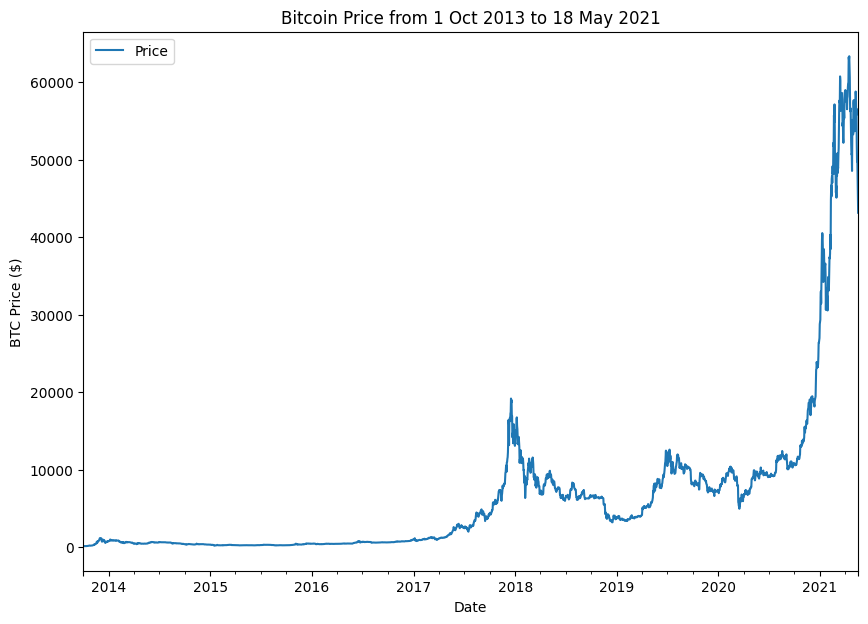

In [6]:
import matplotlib.pyplot as plt
bitcoin_prices.plot(figsize=(10, 7))
plt.ylabel("BTC Price ($)")
plt.title("Bitcoin Price from 1 Oct 2013 to 18 May 2021")
plt.show()

## Importing time series data with Python's CSV module

In [7]:
# Importing and formatting historical data with Python
import csv
from datetime import datetime

timesteps = []
btc_price = []

with open("BTC_USD_2013-10-01_2021-05-18-CoinDesk.csv", "r") as csv_file:
  csv_reader = csv.reader(csv_file, delimiter=",")
  next(csv_reader) # skip header row
  for line in csv_reader:
    timesteps.append(datetime.strptime(line[1], "%Y-%m-%d"))
    btc_price.append(float(line[2]))

# View first 10 of each
timesteps[:10], btc_price[:10]

([datetime.datetime(2013, 10, 1, 0, 0),
  datetime.datetime(2013, 10, 2, 0, 0),
  datetime.datetime(2013, 10, 3, 0, 0),
  datetime.datetime(2013, 10, 4, 0, 0),
  datetime.datetime(2013, 10, 5, 0, 0),
  datetime.datetime(2013, 10, 6, 0, 0),
  datetime.datetime(2013, 10, 7, 0, 0),
  datetime.datetime(2013, 10, 8, 0, 0),
  datetime.datetime(2013, 10, 9, 0, 0),
  datetime.datetime(2013, 10, 10, 0, 0)],
 [123.65499,
  125.455,
  108.58483,
  118.67466,
  121.33866,
  120.65533,
  121.795,
  123.033,
  124.049,
  125.96116])

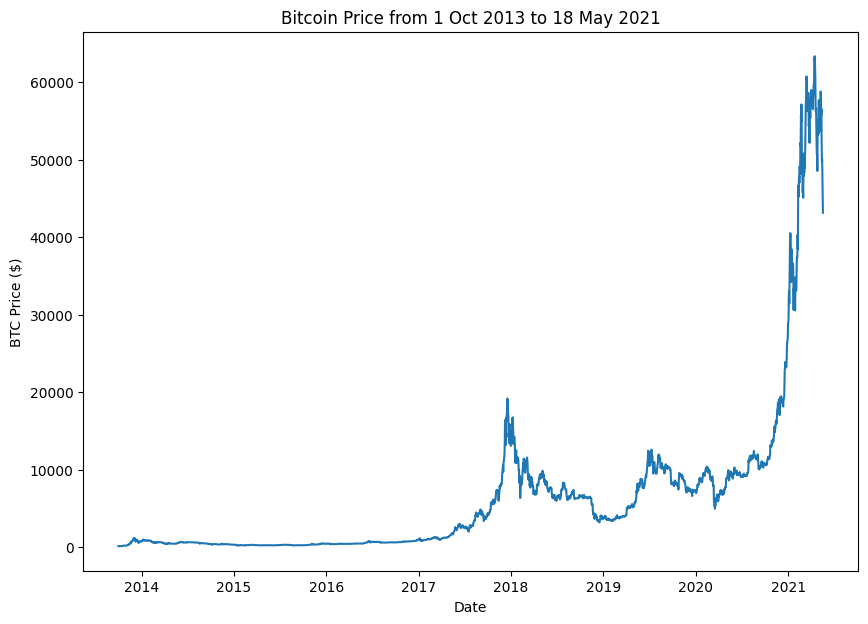

In [8]:
# Plot from CSV
import numpy as np
plt.figure(figsize=(10, 7))
plt.plot(timesteps, btc_price)
plt.ylabel("BTC Price ($)")
plt.title("Bitcoin Price from 1 Oct 2013 to 18 May 2021")
plt.xlabel("Date")
plt.show()

## Format data part 1: Create train and test sets of our time series data

### Creating train and test sets time series data (`the wrong way`)

In [9]:
bitcoin_prices[:5]

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


In [10]:
# Get bitcoin date array
timesteps = bitcoin_prices.index.to_numpy()

In [11]:
timesteps[:5]

array(['2013-10-01T00:00:00.000000000', '2013-10-02T00:00:00.000000000',
       '2013-10-03T00:00:00.000000000', '2013-10-04T00:00:00.000000000',
       '2013-10-05T00:00:00.000000000'], dtype='datetime64[ns]')

In [12]:
prices = bitcoin_prices["Price"].to_numpy()
prices[:5]

array([123.65499, 125.455  , 108.58483, 118.67466, 121.33866])

In [13]:
# Wrong way to make train/test sets for time series data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(timesteps,
                                                    prices,
                                                    test_size=0.2,
                                                    random_state=42)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2229,), (558,), (2229,), (558,))

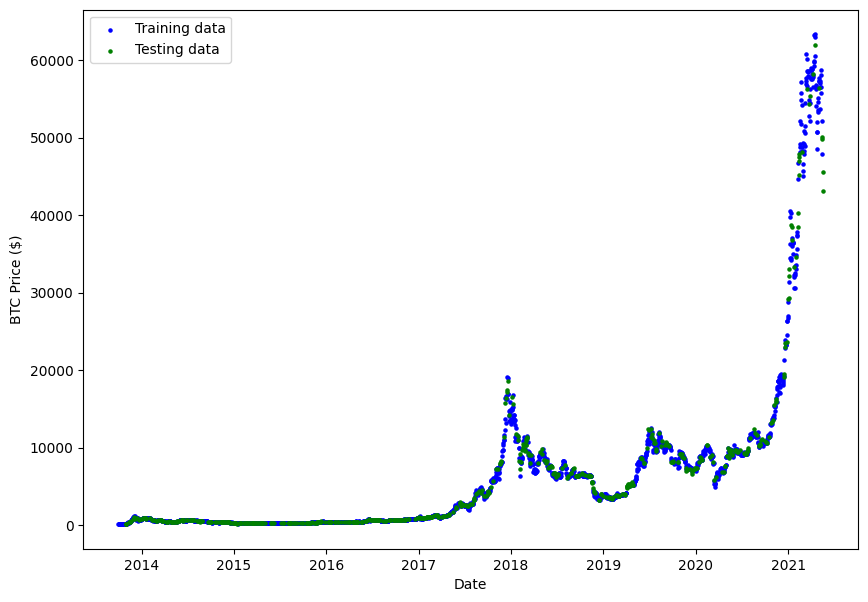

In [15]:
# Let's plot wrong train and test splits
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=5, label="Training data")
plt.scatter(X_test, y_test, c="g", s=5, label="Testing data")
plt.xlabel("Date")
plt.ylabel("BTC Price ($)")
plt.legend()

### Create train & test sets for time series (the right way)

In [16]:
split_size = int(0.8 * len(prices))

X_train, y_train = timesteps[:split_size], prices[:split_size]
X_test, y_test = timesteps[split_size:], prices[split_size:]

len(X_train), len(X_test), len(y_train), len(y_test)

(2229, 558, 2229, 558)

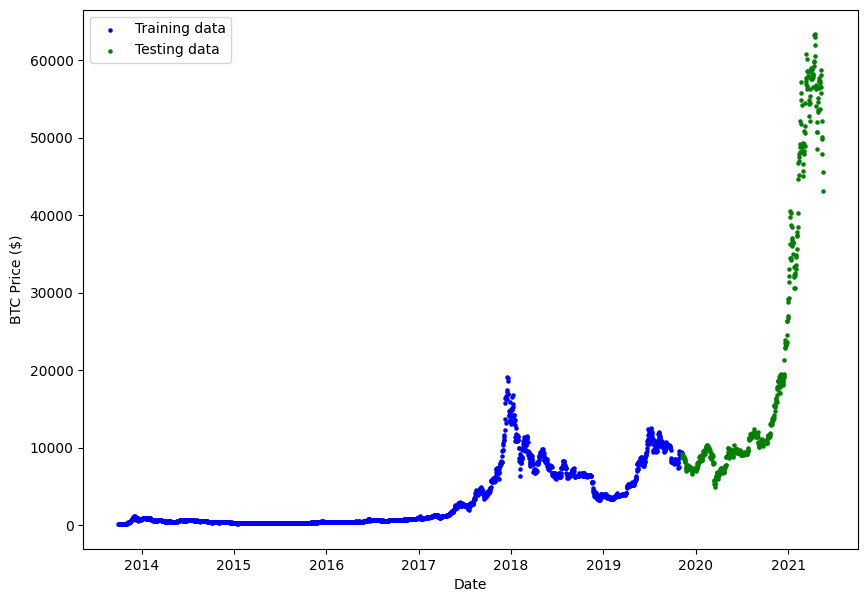

In [17]:
# Plot correctly made splits
plt.figure(figsize=(10, 7))
plt.scatter(X_train, y_train, c="b", s=5, label="Training data")
plt.scatter(X_test, y_test, c="g", s=5, label="Testing data")
plt.xlabel("Date")
plt.ylabel("BTC Price ($)")
plt.legend()

## Create a plotting function

Typing plotting code is tedious, let's functuonize it.

In [18]:
# Create a function to plot time series data
def plot_time_series(timesteps,
                     values,
                     format=".",
                     start=0,
                     end=None,
                     label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across times
  steps).

  Parameters
  ----------
  timesteps : array of timesteps values
  values : array of values across time steps
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (similar to start but for the end)
  label : label to show on plot about values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price ($)")
  if label:
    plt.legend(fontsize=14)
  plt.grid(True)

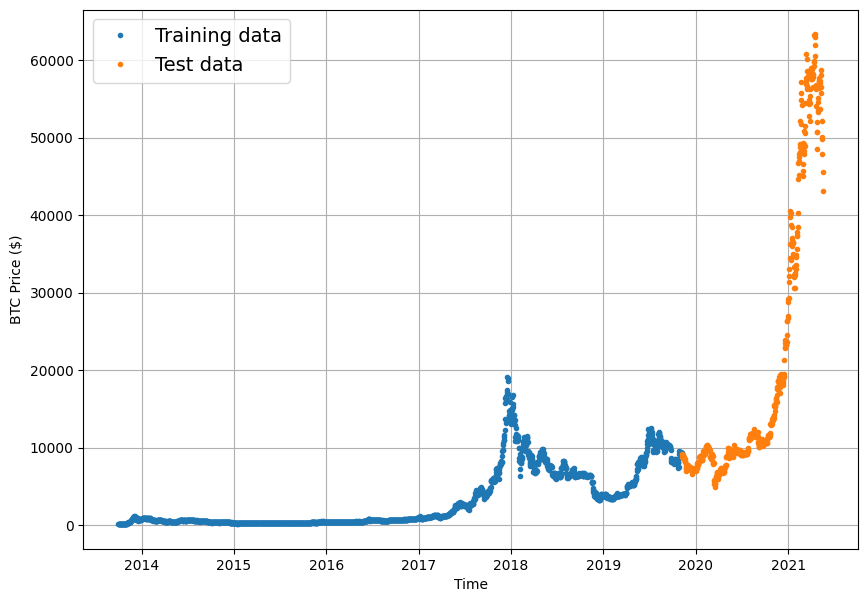

In [19]:
# test out plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Training data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

### Modelling Experiments

0. Naive model (baseline)  `NA NA NA`
1. Dense model, `horizon=1 window=7 NA`
2. Same as model 1, `horizon=1 window=30 NA`
3. Same as model 1, `horizon=7 window=30 NA`
4. Conv1D `horizon=1 window=7 NA`
5. LSTM `horizon=1 window=7 NA`
6. Same as model 1 (but with multivariate data) `horizon=1 window=7 NA` Block reward size
7. N-BEATS algorithmn `horizon=1 window=7 NA`
8. Ensemble (multiple models optimized on different loss functions) `horizon=1 window=7 NA`
9. Future prediction model `horizon=1 window=7 NA`
10. Same as model 1 (but with turkey 🦃 data) `horizon=1 window=7 NA`

## Model 0: Naive Forecast (baseline)

The formula looks like this:  

$$\hat{y}_{t} = y_{t-1}$$

In English:  

> The prediction at timestep t (y-hat) is equal to the value at timestep t-1 (previous timestep) - this is for a horizon of 1.  

**Horizon** = number of timesteps into the feature we're going to predict  
**Window size** = number of timesteps we're going to use to predict **horizon**.

In [20]:
y_test[:5]

array([9226.48582088, 8794.35864452, 8798.04205463, 9081.18687849,
       8711.53433917])

In [21]:
# Create a naive forecast
naive_forecast = y_test[:-1]

In [22]:
naive_forecast[:2], naive_forecast[-2:]

(array([9226.48582088, 8794.35864452]),
 array([47885.62525472, 45604.61575361]))

In [23]:
y_test[-2:] # last value of this doesn't included to naive_forecast

array([45604.61575361, 43144.47129086])

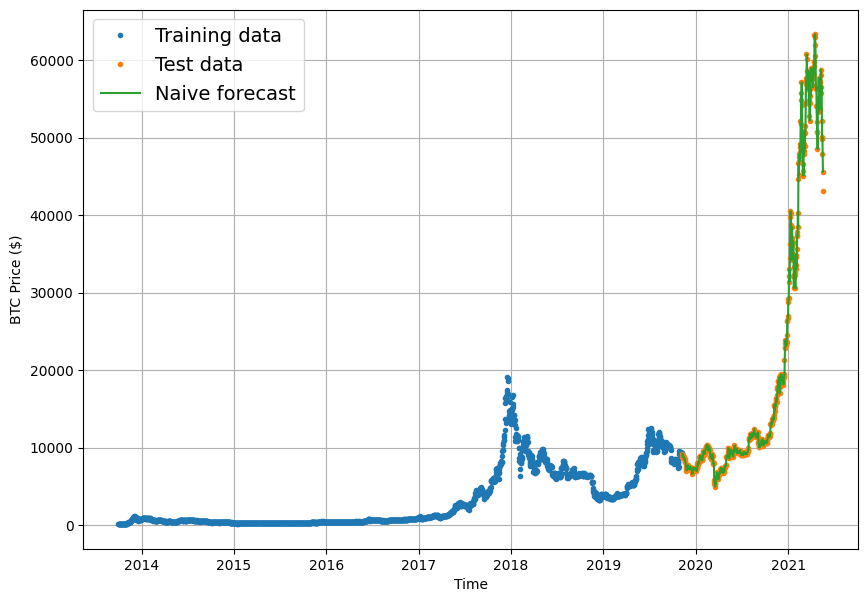

In [24]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Training data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast")

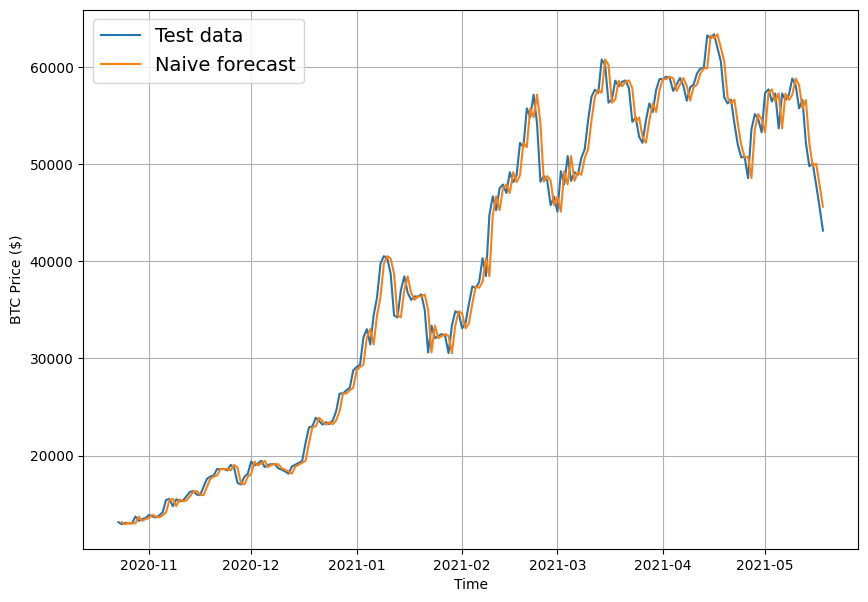

In [25]:

plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test, values=y_test, start=350, format="-", label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, start=350, format="-", label="Naive forecast")

## Evaluating a time series model

We're predicting a number, so that means we have a form of a regression problem.  

A few common regression metrics which can also be used for time series forecasting:  

* MAE - mean absolute error
* MSE - mean squared error
* RMSE - root mean square error
* MAPE/sMAPE - (symetric) mean absolute percentage error
* MASE - mean absolute square error

For all of above metrics, **lower is better**, for example, an MAE of 0 is better than an MAE of 100.  

The main thing we're evaluating here is: **how do our model's forecasts (y_pred) compare against the actual values (y_true) or ground truth values**

In [26]:
import tensorflow as tf

In [27]:
# MASE implementation
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Calculates the mean absolute scaled error for a forecast
  """
  # Calculate the absolute errors
  errors = tf.abs(y_true - y_pred)
  mae = tf.reduce_mean(errors)

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))

  return mae / mae_naive_no_season


In [28]:
import numpy as np

In [29]:
mean_absolute_scaled_error(y_true=y_test[1:],
                           y_pred=(naive_forecast)).numpy()

np.float64(0.9995699939182624)

In [30]:
y_test[0].dtype

dtype('float64')

In [31]:
# Create a function to take in model predictions and truth values and return evaluation metrics
def evaluate_preds(y_true, y_pred):
  # Make sure float32 datatype (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate metrics manually
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))
  mse = tf.reduce_mean(tf.square(y_true - y_pred))
  rmse = tf.sqrt(mse)
  mape = tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100
  mase = mean_absolute_scaled_error(y_true, y_pred)

  return {"mae": mae.numpy(),
          "mse": mse.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape.numpy(),
          "mase": mase.numpy()}

In [32]:
naive_results = evaluate_preds(y_true=y_test[1:], y_pred=naive_forecast)
naive_results

{'mae': np.float32(567.9802),
 'mse': np.float32(1147547.0),
 'rmse': np.float32(1071.2362),
 'mape': np.float32(2.516525),
 'mase': np.float32(0.99957)}

In [33]:
naive_forecast[-10:]

array([57107.12067189, 58788.20967893, 58102.19142623, 55715.54665129,
       56573.5554719 , 52147.82118698, 49764.1320816 , 50032.69313676,
       47885.62525472, 45604.61575361])

In [34]:
tf.reduce_mean(y_test)

<tf.Tensor: shape=(), dtype=float64, numpy=20056.632963737222>

In [35]:
tf.reduce_min(y_test), tf.reduce_max(y_test)

(<tf.Tensor: shape=(), dtype=float64, numpy=4944.7023359837>,
 <tf.Tensor: shape=(), dtype=float64, numpy=63346.7890351052>)

## Other kinds of time series forecasting models which can be used for baselines and actual forecasts
Since we've got a naïve forecast baseline to work with, it's time we start building models to try and beat it.

And because this course is focused on TensorFlow and deep learning, we're going to be using TensorFlow to build deep learning models to try and improve on our naïve forecasting results.

That being said, there are many other kinds of models you may want to look into for building baselines/performing forecasts.

Some of them may even beat our best performing models in this notebook, however, I'll leave trying them out for extra-curriculum.  

Moving average  	https://machinelearningmastery.com/moving-average-smoothing-for-time-series-forecasting-python/  
ARIMA (Autoregression Integrated Moving Average)	  https://machinelearningmastery.com/arima-for-time-series-forecasting-with-python/
sktime (Scikit-Learn for time series)	https://github.com/alan-turing-institute/sktime  
TensorFlow Decision Forests   (random forest, gradient boosting trees)	https://www.tensorflow.org/decision_forests  
Facebook Kats   (purpose-built forecasting and time series analysis library by Facebook)	https://github.com/facebookresearch/Kats  
LinkedIn Greykite   (flexible, intuitive and fast forecasts)	https://github.com/linkedin/greykite

## Formatting Data Part 2: Windowing our dataset

Why do we window?  

Windowing is a method to turn a time series dataset into supervised learning problem.  

In other words, we want to use windows of the past to predict the future.  

For example for a univariate time series, windowing for one week (window=7) to predict the next single value (horizon=1) might look like:  

Window for one week (univariate time series)  

[0, 1, 2, 3, 4, 5, 6] -> [7]  
[1, 2, 3, 4, 5, 6, 7] -> [8]  
[2, 3, 4, 5, 6, 7, 8] -> [9]  
Or for the price of Bitcoin, it'd look like:  

Window for one week with the target of predicting the next day (Bitcoin prices)  

[123.654, 125.455, 108.584, 118.674, 121.338, 120.655, 121.795] -> [123.033]   
[125.455, 108.584, 118.674, 121.338, 120.655, 121.795, 123.033] -> [124.049]  
[108.584, 118.674, 121.338, 120.655, 121.795, 123.033, 124.049] -> [125.961]  

```
Let's build some functions which take in a univariate time series and turn it into windows and horizons of specified sizes.  

We'll start with the default horizon size of 1 and a window size of 7 (these aren't necessarily the best values to use, I've just picked them).  
```  

In [36]:
# What we want to do with our Bitcoin data
print(f"We want to use : {btc_price[:7]} \nto predict this: {btc_price[7]}")


We want to use : [123.65499, 125.455, 108.58483, 118.67466, 121.33866, 120.65533, 121.795] 
to predict this: 123.033


In [37]:
# Let's setup glocal variable variables for window and horizon size

HORIZON = 1 # predicts next 1 day
WINDOW_SIZE = 7 # use the past week of Bitcoin data to amke the predction

In [38]:
# Create function to label windowed data
def get_labelled_windows(x, horizon=HORIZON):
  """
  Creates labels for windowed dataset

  E.g. if horizon=1
  Input: [0, 1, 2, 3, 4, 5, 6] -> Output: ([0, 1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [39]:
# Test out window labeling func
test_window, test_label = get_labelled_windows(tf.expand_dims(tf.range(8), axis=0))

In [40]:
test_window, test_label

(<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[0, 1, 2, 3, 4, 5, 6]], dtype=int32)>,
 <tf.Tensor: shape=(1, 1), dtype=int32, numpy=array([[7]], dtype=int32)>)

In [41]:
print(f"Window: {tf.squeeze(test_window).numpy()} \nLabel: {tf.squeeze(test_label).numpy()}")

Window: [0 1 2 3 4 5 6] 
Label: 7


Mounted at /content/drive


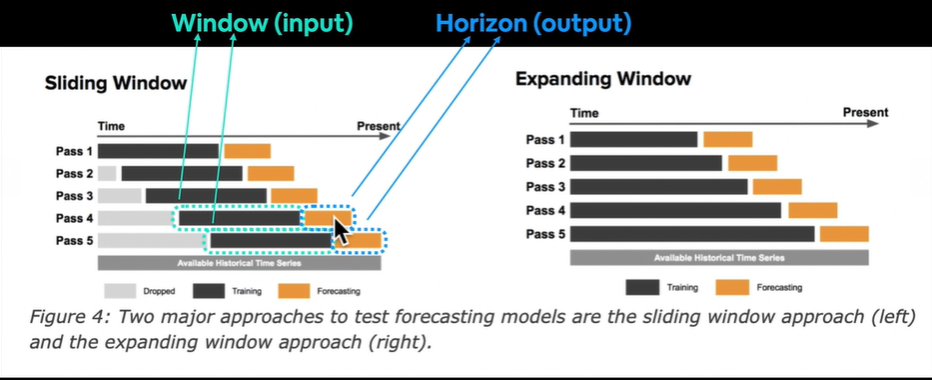

In [42]:
from google.colab import drive
drive.mount("/content/drive")

from IPython.display import Image, display

display(Image("/content/drive/MyDrive/Deep Learning/window_horizon.png"))

Now, we'll create a function provides us these steps:  
1. Create a window step of specific window size (e.g. [0, 1, 2, 3, 4, 5, 6])  
2. Use Numpy indexing to create a 2D array of multiple window steps, for example:
```
[0, 1, 2, 3, 4, 5, 6]
[1, 2, 3, 4, 5, 6, 7]
[2, 3, 4, 5, 6, 7, 8]
```
3. Uses the 2D array of multiple window steps (from 2.) to index on a target series (e.g. the historical price of Bitcoin)  
4. Uses our `get_labelled_windows()` function we created above to turn the window steps into windows with a secified horizon.  

⚓ Resource:  
https://towardsdatascience.com/how-to-speedup-data-processing-with-numpy-vectorization-12acac71cfca/

In [43]:
np.expand_dims(np.arange(8), axis=0)

array([[0, 1, 2, 3, 4, 5, 6, 7]])

In [44]:
# Create function to view Numpy arrays as windows
def make_windows(x, windows_size=WINDOW_SIZE, horizon=HORIZON):
  """
  Turns a 1D array into 2D array of sequential labelled windows of window_size with horizon size labels.
  """
  # 1. Create a window of specific window_size (aadd the horizon on the end for labelling later)
  window_step = np.expand_dims(np.arange(windows_size + horizon), axis=0)

  # 2 Create a 2D array of multiple window  steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x) - (windows_size + horizon - 1)), axis=0).T
  print(f"Window indexes:\n {window_indexes, window_indexes.shape}")

In [45]:
make_windows(prices, windows_size=WINDOW_SIZE, horizon=HORIZON)

Window indexes:
 (array([[   0,    1,    2, ...,    5,    6,    7],
       [   1,    2,    3, ...,    6,    7,    8],
       [   2,    3,    4, ...,    7,    8,    9],
       ...,
       [2777, 2778, 2779, ..., 2782, 2783, 2784],
       [2778, 2779, 2780, ..., 2783, 2784, 2785],
       [2779, 2780, 2781, ..., 2784, 2785, 2786]]), (2780, 8))


In [46]:
len(prices)

2787

In [47]:
prices[2786] == prices[-1]

np.True_

In [48]:
# Create function to view Numpy arrays as windows
def make_windows(x, windows_size=WINDOW_SIZE, horizon=HORIZON):
  """
  Turns a 1D array into 2D array of sequential labelled windows of window_size with horizon size labels.
  """
  # 1. Create a window of specific window_size (aadd the horizon on the end for labelling later)
  window_step = np.expand_dims(np.arange(windows_size + horizon), axis=0)

  # 2 Create a 2D array of multiple window  steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x) - (windows_size + horizon - 1)), axis=0).T
  print(f"Window indexes:\n {window_indexes, window_indexes.shape}")

  # 3. Index on the target array (a time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]
  print(f"Windowed array:\n {windowed_array, windowed_array.shape}")

  # 4. Get the labelled windows
  windows, labels = get_labelled_windows(windowed_array, horizon=horizon)
  print(f"Windows:\n {windows, windows.shape}")
  print(f"Labels:\n {labels, labels.shape}")

  return windows, labels

In [49]:
full_windows, full_labels = make_windows(prices, windows_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

Window indexes:
 (array([[   0,    1,    2, ...,    5,    6,    7],
       [   1,    2,    3, ...,    6,    7,    8],
       [   2,    3,    4, ...,    7,    8,    9],
       ...,
       [2777, 2778, 2779, ..., 2782, 2783, 2784],
       [2778, 2779, 2780, ..., 2783, 2784, 2785],
       [2779, 2780, 2781, ..., 2784, 2785, 2786]]), (2780, 8))
Windowed array:
 (array([[  123.65499   ,   125.455     ,   108.58483   , ...,
          120.65533   ,   121.795     ,   123.033     ],
       [  125.455     ,   108.58483   ,   118.67466   , ...,
          121.795     ,   123.033     ,   124.049     ],
       [  108.58483   ,   118.67466   ,   121.33866   , ...,
          123.033     ,   124.049     ,   125.96116   ],
       ...,
       [58788.20967893, 58102.19142623, 55715.54665129, ...,
        49764.1320816 , 50032.69313676, 47885.62525472],
       [58102.19142623, 55715.54665129, 56573.5554719 , ...,
        50032.69313676, 47885.62525472, 45604.61575361],
       [55715.54665129, 56573.5554719

(2780, 2780)

In [50]:
# View the first 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i]} \nLabel: {full_labels[i]}")

Window: [123.65499 125.455   108.58483 118.67466 121.33866 120.65533 121.795  ] 
Label: [123.033]
Window: [125.455   108.58483 118.67466 121.33866 120.65533 121.795   123.033  ] 
Label: [124.049]
Window: [108.58483 118.67466 121.33866 120.65533 121.795   123.033   124.049  ] 
Label: [125.96116]


In [51]:
# View the last 3 windows/labels
for i in range(3):
  print(f"Window: {full_windows[i-3]} \nLabel: {full_labels[i-3]}")

Window: [58788.20967893 58102.19142623 55715.54665129 56573.5554719
 52147.82118698 49764.1320816  50032.69313676] 
Label: [47885.62525472]
Window: [58102.19142623 55715.54665129 56573.5554719  52147.82118698
 49764.1320816  50032.69313676 47885.62525472] 
Label: [45604.61575361]
Window: [55715.54665129 56573.5554719  52147.82118698 49764.1320816
 50032.69313676 47885.62525472 45604.61575361] 
Label: [43144.47129086]


In [52]:
prices[-1]

np.float64(43144.4712908603)

⚓**Note:** There's a functions which does similar to the above in `tf.keras.preprocessing`, an extension could be to try an replicate what we've done using the premade function:  

https://www.tensorflow.org/api_docs/python/tf/keras/preprocessing/timeseries_dataset_from_array

## Turning windows into training and test sets

Time to turn our windows into training and test splits.  

We could've windowed our existing training and test splits, however, with the nature of windowing (windowing often requires an offset at some point in the data), it usually works better to window the data first, then split it into training and test sets.  

Let's write a function which takes in full sets of windows and their labels and splits them into train and test splits.  

In [53]:
# Make the train/test splits
def make_train_test_splits(windows, labels, test_split=0.2):
  """
  Splits matching pairs of windows and labels into train and test splits.
  """
  split_size = int(len(windows) * (1-test_split)) # this will default to 80% train/20% test
  train_windows = windows[:split_size]
  train_labels = labels[:split_size]
  test_windows = windows[split_size:]
  test_labels = labels[split_size:]
  return train_windows, test_windows, train_labels, test_labels

In [54]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

In [55]:
train_windows[:5], train_labels[:5]

(array([[123.65499, 125.455  , 108.58483, 118.67466, 121.33866, 120.65533,
         121.795  ],
        [125.455  , 108.58483, 118.67466, 121.33866, 120.65533, 121.795  ,
         123.033  ],
        [108.58483, 118.67466, 121.33866, 120.65533, 121.795  , 123.033  ,
         124.049  ],
        [118.67466, 121.33866, 120.65533, 121.795  , 123.033  , 124.049  ,
         125.96116],
        [121.33866, 120.65533, 121.795  , 123.033  , 124.049  , 125.96116,
         125.27966]]),
 array([[123.033  ],
        [124.049  ],
        [125.96116],
        [125.27966],
        [125.9275 ]]))

In [56]:
# Check to see if same (accounting for horizon and window size)
np.array_equal(np.squeeze(train_labels[:-HORIZON-1]), y_train[WINDOW_SIZE:])

True

## Make a modelling checkpoint

We're so close to building models. So so so close.

Because our model's performance will fluctuate from experiment to experiment, we'll want to make sure we're comparing apples to apples.

What I mean by this is in order for a fair comparison, we want to compare each model's best performance against each model's best performance.

For example, if model_1 performed incredibly well on epoch 55 but its performance fell off toward epoch 100, we want the version of the model from epoch 55 to compare to other models rather than the version of the model from epoch 100.  

And the same goes for each of our other models: compare the best against the best.  

To take of this, we'll implement a ModelCheckpoint callback.  

The ModelCheckpoint callback will monitor our model's performance during training and save the best model to file by setting save_best_only=True.  

That way when evaluating our model we could restore its best performing configuration from file.  

⚓ Note: Because of the size of the dataset (smaller than usual), you'll notice our modelling experiment results fluctuate quite a bit during training (hence the implementation of the ModelCheckpoint callback to save the best model).  

Because we're going to be running multiple experiments, it makes sense to keep track of them by saving models to file under different names.  

To do this, we'll write a small function to create a ModelCheckpoint callback which saves a model to specified filename.  

In [57]:
import os

def create_model_checkpoint(model_name, save_path="model_experiments"):
    return tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(save_path, model_name + ".keras"),
        monitor="val_loss",
        verbose=0,
        save_best_only=True
    )

## Model 1: Dense model (window = 7, horizon = 1)  

Time to build one of our models.  

If you think we've been through a fair bit of preprocessing before getting here, you're right.  

Often, preparing data for a model is one of the largest parts of any machine learning project.  

And once you've got a good model in place, you'll probably notice far more improvements from manipulating the data (e.g. collecting more, improving the quality) than manipulating the model.  

We're going to start by keeping it simple, model_1 will have:  

* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)  
* Adam optimizer and MAE loss function  
* Batch size of 128  
* 100 epochs  
Why these values?  

I picked them out of experimentation.  

A batch size of 32 works pretty well too and we could always train for less epochs but since the model runs so fast (you'll see in a second, it's because the number of samples we have isn't massive) we might as well train for more.

⚓ Note: As always, many of the values for machine learning problems are experimental. A reminder that the values you can set yourself in a machine learning algorithm (the hidden units, the batch size, horizon size, window size) are called hyperparameters. And experimenting to find the best values for hyperparameters is called hyperparameter tuning. Where as parameters learned by a model itself (patterns in the data, formally called weights & biases) are referred to as parameters.  

Let's import TensorFlow and build our first deep learning model for time series.  

In [58]:
import tensorflow as tf
from tensorflow.keras import layers

# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_1 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
], name="model_1_dense") # give the model a name so we can save it

# Compile model
model_1.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_1.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_1.name)]) # create ModelCheckpoint callback to save best model

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 834.1782 - mae: 834.1782 - val_loss: 2207.1394 - val_mae: 2207.1394
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 270.4181 - mae: 270.4181 - val_loss: 1253.2596 - val_mae: 1253.2596
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 214.4924 - mae: 214.4924 - val_loss: 1131.5417 - val_mae: 1131.5417
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 201.4158 - mae: 201.4158 - val_loss: 1139.4624 - val_mae: 1139.4624
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 194.7048 - mae: 194.7048 - val_loss: 1097.2332 - val_mae: 1097.2332
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 189.8436 - mae: 189.8436 - val_loss: 1066.9702 - val_mae: 1066.9702
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 183.8911 - mae: 183.8911 - val_loss: 1024.0596 - val_mae: 1024.0596
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 177.4299 - mae: 177.4299 - val_loss: 985.2961 - val

In [59]:
# Evaluate model on test data
model_1.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 575.8159 - mae: 575.8159


[575.81591796875, 575.81591796875]

In [60]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/model_1_dense.keras")
model_1.evaluate(test_windows, test_labels)


18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 565.1859 - mae: 565.1859


[565.1858520507812, 565.1858520507812]

In [61]:
naive_results

{'mae': np.float32(567.9802),
 'mse': np.float32(1147547.0),
 'rmse': np.float32(1071.2362),
 'mape': np.float32(2.516525),
 'mase': np.float32(0.99957)}

## Making forecasts with a model (on the test dataset)  

We've trained a model and evaluated the it on the test data, but the project we're working on is called BitPredict 💰📈 so how do you think we could use our model to make predictions?  

Since we're going to be running more modelling experiments, let's write a function which:  

1. Takes in a trained model (just like model_1)
2. Takes in some input data (just like the data the model was trained on)
3. Passes the input data to the model's predict() method
4. Returns the predictions

In [62]:
def make_preds(model, input_data):
  """
  Uses model to make predictions on input_data.

  Parameters
  ----------
  model: trained model
  input_data: windowed input data (same kind of data model was trained on)

  Returns model predictions on input_data.
  """
  forecast = model.predict(input_data)
  return tf.squeeze(forecast) # return 1D array of predictions

In [63]:
# Make predictions using model_1 on the test dataset and view the results
model_1_preds = make_preds(model_1, test_windows)
len(model_1_preds), model_1_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


(556,
 <tf.Tensor: shape=(10,), dtype=float32, numpy=
 array([8841.109, 8795.226, 9036.386, 8774.289, 8749.126, 8723.224,
        8669.183, 8539.472, 8448.407, 8526.404], dtype=float32)>)

⚓ **Note:** With these outputs, our model isn't forecasting yet. It's only making predictions on the test dataset. Forecasting would involve a model making predictions into the future, however, the test dataset is only a pseudofuture.

In [64]:
# Evaluate preds
model_1_results = evaluate_preds(y_true=tf.squeeze(test_labels), # reduce to right shape
                                 y_pred=model_1_preds)
model_1_results

{'mae': np.float32(565.18585),
 'mse': np.float32(1157886.4),
 'rmse': np.float32(1076.0513),
 'mape': np.float32(2.519447),
 'mase': np.float32(0.992875)}

In [65]:
naive_results

{'mae': np.float32(567.9802),
 'mse': np.float32(1147547.0),
 'rmse': np.float32(1071.2362),
 'mape': np.float32(2.516525),
 'mase': np.float32(0.99957)}

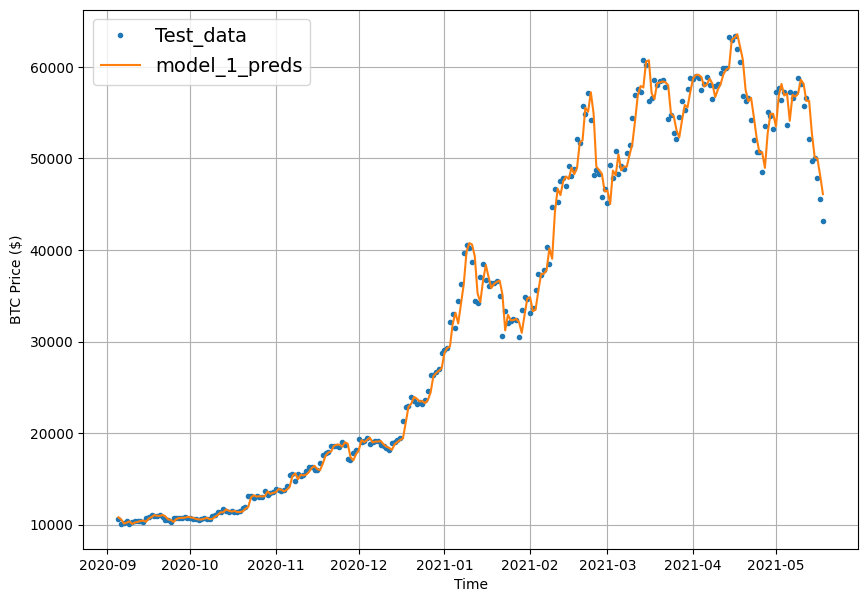

In [66]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="model_1_preds")

What's wrong with these predictions?  

As mentioned before, they're on the test dataset. So they're not actual forecasts.  

With our current model setup, how do you think we'd make forecasts for the future?  

Have a think about it for now, we'll cover this later on.  

## Model 2: Dense (window = 30, horizon = 1)  

A naïve model is currently beating our handcrafted deep learning model.   

We can't let this happen.  

Let's continue our modelling experiments.  

We'll keep the previous model architecture but use a window size of 30.  

In other words, we'll use the previous 30 days of Bitcoin prices to try and predict the next day price.  

In [67]:
HORIZON = 1 # predict one step at a time
WINDOW_SIZE = 30 # use 30 timesteps in the past

In [68]:
# Make windowed data with appropriate horizon and window sizes
full_windows, full_labels = make_windows(prices, windows_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

Window indexes:
 (array([[   0,    1,    2, ...,   28,   29,   30],
       [   1,    2,    3, ...,   29,   30,   31],
       [   2,    3,    4, ...,   30,   31,   32],
       ...,
       [2754, 2755, 2756, ..., 2782, 2783, 2784],
       [2755, 2756, 2757, ..., 2783, 2784, 2785],
       [2756, 2757, 2758, ..., 2784, 2785, 2786]]), (2757, 31))
Windowed array:
 (array([[  123.65499   ,   125.455     ,   108.58483   , ...,
          192.75666   ,   197.4       ,   196.02499   ],
       [  125.455     ,   108.58483   ,   118.67466   , ...,
          197.4       ,   196.02499   ,   198.04883   ],
       [  108.58483   ,   118.67466   ,   121.33866   , ...,
          196.02499   ,   198.04883   ,   198.93233   ],
       ...,
       [63346.78903511, 61965.7825981 , 60574.44472823, ...,
        49764.1320816 , 50032.69313676, 47885.62525472],
       [61965.7825981 , 60574.44472823, 56850.83016569, ...,
        50032.69313676, 47885.62525472, 45604.61575361],
       [60574.44472823, 56850.830165

(2757, 2757)

In [69]:
tf.random.set_seed(42)

# Create model (same model as model 1 but data input will be different)
model_2 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON) # need to predict horizon number of steps into the future
], name="model_2_dense")

model_2.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

model_2.fit(train_windows,
            train_labels,
            epochs=100,
            batch_size=128,
            verbose=1,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_2.name)])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 1548.8398 - mae: 1548.8398 - val_loss: 1424.9080 - val_mae: 1424.9080
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 323.0309 - mae: 323.0309 - val_loss: 1748.7332 - val_mae: 1748.7332
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 191.7746 - mae: 191.7746 - val_loss: 960.2271 - val_mae: 960.2271
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 151.0967 - mae: 151.0967 - val_loss: 846.8193 - val_mae: 846.8193
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 147.4992 - mae: 147.4992 - val_loss: 828.0589 - val_mae: 828.0589
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 144.2976 - mae: 144.2976 - val_loss: 829.4376 - val_mae: 829.4376
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 142.0647 - mae: 142.0647 - val_loss: 783.6483 - val_mae: 783.6483
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 139.0311 - mae: 139.0311 - val_loss: 796.3641 - val_mae: 7

In [70]:
# Evaluate model 2 preds
model_2.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 570.1451 - mae: 570.1451


[570.1450805664062, 570.1450805664062]

In [71]:
# Load in best performing model
model_2 = tf.keras.models.load_model("model_experiments/model_2_dense.keras")
model_2.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 569.9407 - mae: 569.9407


[569.940673828125, 569.940673828125]

In [72]:
naive_results

{'mae': np.float32(567.9802),
 'mse': np.float32(1147547.0),
 'rmse': np.float32(1071.2362),
 'mape': np.float32(2.516525),
 'mase': np.float32(0.99957)}

In [73]:
# Get forecast predictions
model_2_preds = make_preds(model_2,
                           input_data=test_windows)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [74]:
# Evaluate results for model 2 predictions
model_2_results = evaluate_preds(y_true=tf.squeeze(test_labels), # remove 1 dimension of test labels
                                 y_pred=model_2_preds)
model_2_results


{'mae': np.float32(569.9406),
 'mse': np.float32(1173131.2),
 'rmse': np.float32(1083.1118),
 'mape': np.float32(2.5444512),
 'mase': np.float32(1.0012279)}

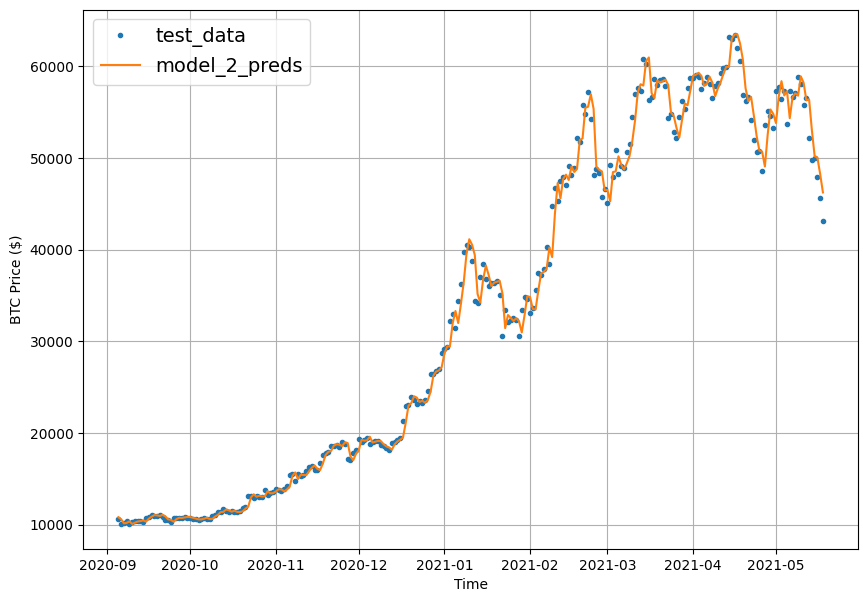

In [75]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="model_2_preds")

## Model 3: Dense (window = 30, horizon = 7)

Let's try and predict 7 days ahead given the previous 30 days.  

First, we'll update the HORIZON and WINDOW_SIZE variables and create windowed data.  

In [76]:
HORIZON = 7
WINDOW_SIZE = 30

full_windows, full_labels = make_windows(prices, windows_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

Window indexes:
 (array([[   0,    1,    2, ...,   34,   35,   36],
       [   1,    2,    3, ...,   35,   36,   37],
       [   2,    3,    4, ...,   36,   37,   38],
       ...,
       [2748, 2749, 2750, ..., 2782, 2783, 2784],
       [2749, 2750, 2751, ..., 2783, 2784, 2785],
       [2750, 2751, 2752, ..., 2784, 2785, 2786]]), (2751, 37))
Windowed array:
 (array([[  123.65499   ,   125.455     ,   108.58483   , ...,
          210.3075    ,   225.02      ,   248.25333   ],
       [  125.455     ,   108.58483   ,   118.67466   , ...,
          225.02      ,   248.25333   ,   262.32666   ],
       [  108.58483   ,   118.67466   ,   121.33866   , ...,
          248.25333   ,   262.32666   ,   294.48699   ],
       ...,
       [58171.9090187 , 59295.95004401, 59822.90167743, ...,
        49764.1320816 , 50032.69313676, 47885.62525472],
       [59295.95004401, 59822.90167743, 59853.19724227, ...,
        50032.69313676, 47885.62525472, 45604.61575361],
       [59822.90167743, 59853.197242

(2751, 2751)

In [77]:
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows=full_windows, labels=full_labels, test_split=0.2)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2200, 551, 2200, 551)

In [78]:
tf.random.set_seed(42)

# Create model (same as model_1 except with different data input size)
model_3 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
], name="model_3_dense")

model_3.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

model_3.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=1,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_3.name)])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 2297.8713 - mae: 2297.8713 - val_loss: 3618.8091 - val_mae: 3618.8091
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 625.8594 - mae: 625.8594 - val_loss: 2632.5608 - val_mae: 2632.5608
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 463.1641 - mae: 463.1641 - val_loss: 2258.5916 - val_mae: 2258.5916
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 410.8641 - mae: 410.8641 - val_loss: 2230.3516 - val_mae: 2230.3516
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 377.0496 - mae: 377.0496 - val_loss: 2018.4390 - val_mae: 2018.4390
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 345.3382 - mae: 345.3382 - val_loss: 1850.0112 - val_mae: 1850.0112
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 322.5244 - mae: 322.5244 - val_loss: 1765.0466 - val_mae: 1765.0466
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 309.4630 - mae: 309.4630 - val_loss: 1664.3755 - 

In [79]:
# How did our model with a larger window size and horizon go?
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 1243.5839 - mae: 1243.5839


[1243.5838623046875, 1243.5838623046875]

In [80]:
# Load in best version of model_3 and evaluate
model_3 = tf.keras.models.load_model("model_experiments/model_3_dense.keras")
model_3.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1237.7833 - mae: 1237.7833


[1237.7833251953125, 1237.7833251953125]

In [81]:
# The predictions are going to be 7 steps at a time (this is the HORIZON size)
model_3_preds = make_preds(model_3,
                           input_data=test_windows)
model_3_preds[:5]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


<tf.Tensor: shape=(5, 7), dtype=float32, numpy=
array([[9492.564, 9345.358, 9257.488, 9387.472, 9400.547, 9221.964,
        9116.141],
       [9261.96 , 9369.888, 9008.844, 9119.18 , 9255.82 , 9074.059,
        8935.591],
       [8930.462, 9111.225, 9023.173, 8997.911, 9131.521, 9269.275,
        8752.428],
       [8958.669, 9028.806, 9183.562, 9157.691, 9239.425, 9514.152,
        8960.988],
       [8852.32 , 8953.725, 8990.995, 8948.324, 9204.769, 9350.147,
        8944.078]], dtype=float32)>

In [82]:
# Calculate model_3 results - these are going to be multi-dimensional because
# we're trying to predict more than one step at a time.
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
model_3_results

{'mae': np.float32(1237.7836),
 'mse': np.float32(5296453.0),
 'rmse': np.float32(2301.4023),
 'mape': np.float32(5.6722775),
 'mase': np.float32(2.2025666)}

## Make our evaluation function work for larger horizons

In [83]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))
  mse = tf.reduce_mean(tf.square(y_true - y_pred))
  rmse = tf.sqrt(mse)
  mape = tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100
  mase = mean_absolute_scaled_error(y_true, y_pred)

  # Account for different sized metrics (for longer horizons, reduce to single number)
  if mae.ndim > 0: # if mae isn't already a scalar, reduce it to one by aggregating tensors to mean
    mae = tf.reduce_mean(mae)
    mse = tf.reduce_mean(mse)
    rmse = tf.reduce_mean(rmse)
    mape = tf.reduce_mean(mape)
    mase = tf.reduce_mean(mase)

  return {"mae": mae.numpy(),
          "mse": mse.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape.numpy(),
          "mase": mase.numpy()}

In [84]:
# Get model_3 results aggregated to single values
model_3_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_3_preds)
model_3_results

{'mae': np.float32(1237.7836),
 'mse': np.float32(5296453.0),
 'rmse': np.float32(2301.4023),
 'mape': np.float32(5.6722775),
 'mase': np.float32(2.2025666)}

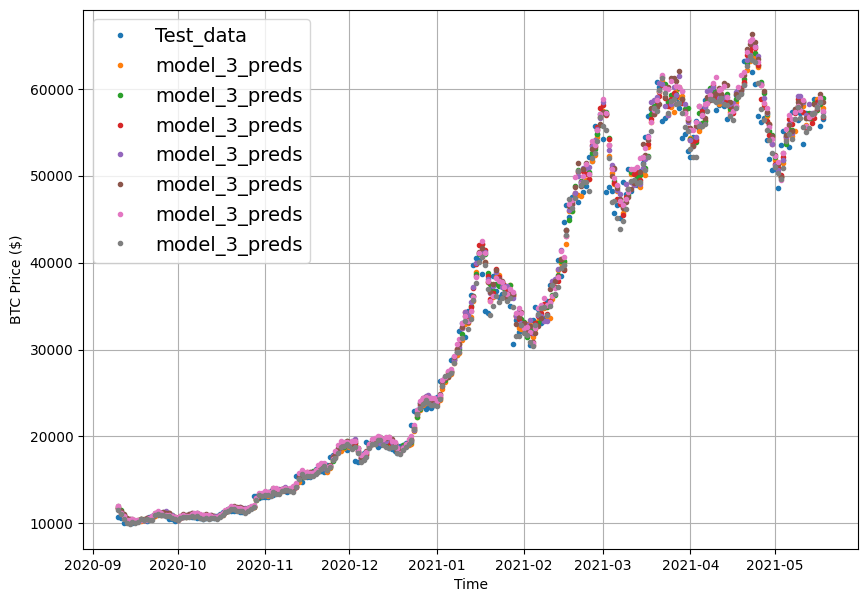

In [85]:
offset = 300
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=test_labels[:, 0],
                 start=offset,
                 label="Test_data")
# Checking the shape of model_3_preds results in [n_test_samples, HORIZON] (this will screw up the plot)
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=model_3_preds,
                 start=offset,
                 label="model_3_preds")

⚓ Note: Aggregating the predictions (e.g. reducing a 7-day horizon to one value such as the mean) loses information from the original prediction. As in, the model predictions were trained to be made for 7-days but by reducing them to one, we gain the ability to plot them visually but we lose the extra information contained across multiple days.

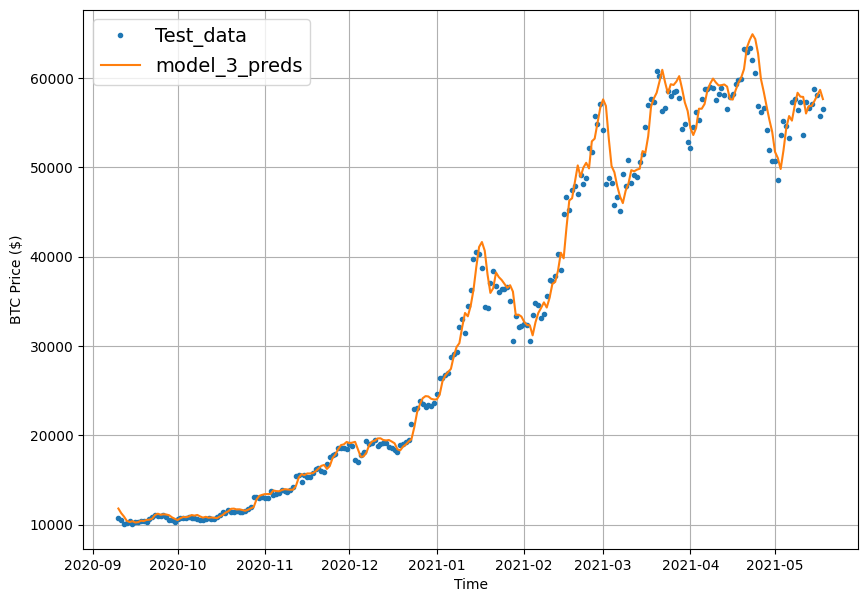

In [86]:
offset = 300
plt.figure(figsize=(10, 7))
# Plot model_3_preds by aggregating them (note: this condenses information so the preds will look fruther ahead than the test data)
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=test_labels[:, 0],
                 start=offset,
                 label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):],
                 values=tf.reduce_mean(model_3_preds, axis=1), # this time average
                 format="-",
                 start=offset,
                 label="model_3_preds")

## Which of our models is performing best so far?

So far, we've trained 3 models which use the same architecture but use different data inputs.  

Let's compare them with the naïve model to see which model is performing the best so far.  

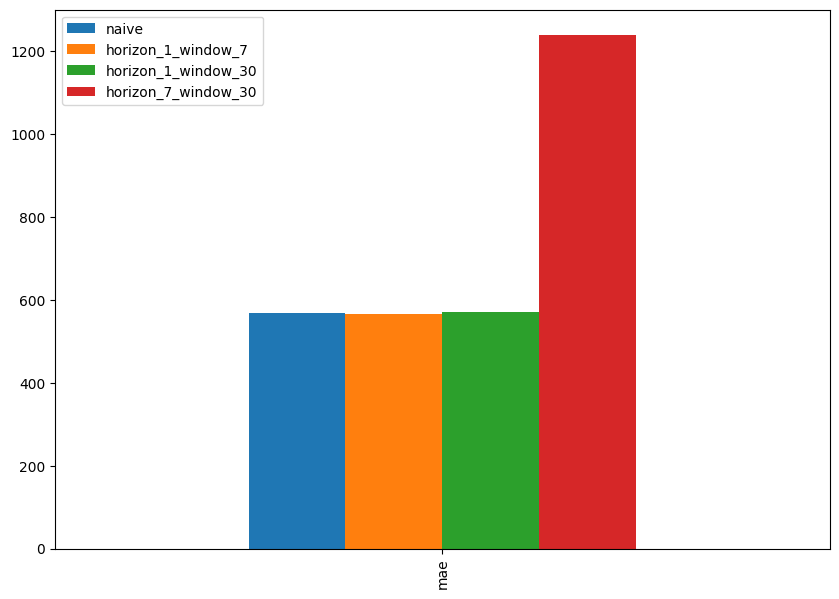

In [87]:
pd.DataFrame({"naive": naive_results["mae"],
              "horizon_1_window_7": model_1_results["mae"],
              "horizon_1_window_30": model_2_results["mae"],
              "horizon_7_window_30": model_3_results["mae"]}, index=["mae"]).plot(figsize=(10, 7), kind="bar");


⚓ Note: You might be wondering, why are the naïve results so good? One of the reasons could be due the presence of autocorrelation in the data. If a time series has autocorrelation it means the value at t+1 (the next timestep) is typically close to the value at t (the current timestep). In other words, today's value is probably pretty close to yesterday's value. Of course, this isn't always the case but when it is, a naïve model will often get fairly good results.

## Model 4: Conv1D

This time, we'll be using a Conv1D model. Because as we saw in the sequence modelling notebook, Conv1D models can be used for seq2seq (sequence to sequence) problems.  

In our case, the input sequence is the previous 7 days of Bitcoin price data and the output is the next day (in seq2seq terms this is called a many to one problem).  

Framing Bitcoin forecasting in seq2seq (sequence to sequence) terms. Using a window size of 7 and a horizon of one results in a many to one problem. Using a window size of >1 and a horizon of >1 results in a many to many problem.

In [88]:
HORIZON = 1 # predict next day
WINDOW_SIZE = 7 # use previous week worth of data

In [89]:
# Create windowed dataset
full_windows, full_labels = make_windows(prices, windows_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

Window indexes:
 (array([[   0,    1,    2, ...,    5,    6,    7],
       [   1,    2,    3, ...,    6,    7,    8],
       [   2,    3,    4, ...,    7,    8,    9],
       ...,
       [2777, 2778, 2779, ..., 2782, 2783, 2784],
       [2778, 2779, 2780, ..., 2783, 2784, 2785],
       [2779, 2780, 2781, ..., 2784, 2785, 2786]]), (2780, 8))
Windowed array:
 (array([[  123.65499   ,   125.455     ,   108.58483   , ...,
          120.65533   ,   121.795     ,   123.033     ],
       [  125.455     ,   108.58483   ,   118.67466   , ...,
          121.795     ,   123.033     ,   124.049     ],
       [  108.58483   ,   118.67466   ,   121.33866   , ...,
          123.033     ,   124.049     ,   125.96116   ],
       ...,
       [58788.20967893, 58102.19142623, 55715.54665129, ...,
        49764.1320816 , 50032.69313676, 47885.62525472],
       [58102.19142623, 55715.54665129, 56573.5554719 , ...,
        50032.69313676, 47885.62525472, 45604.61575361],
       [55715.54665129, 56573.5554719

(2780, 2780)

In [90]:
# Create train/test splits
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(full_windows, full_labels)
len(train_windows), len(test_windows), len(train_labels), len(test_labels)

(2224, 556, 2224, 556)

Now, since we're going to be using Conv1D layers, we need to make sure our input shapes are correct.  

The Conv1D layer in TensorFlow takes an input of: (batch_size, timesteps, input_dim).  

In our case, the batch_size (by default this is 32 but we can change it) is handled for us but the other values will be:  

* timesteps = WINDOW_SIZE - the timesteps is also often referred to as features, our features are the previous WINDOW_SIZE values of Bitcoin  
* input_dim = HORIZON - our model views WINDOW_SIZE (one week) worth of data at a time to predict HORIZON (one day)  

Right now, our data has the timesteps dimension ready but we'll have to adjust it to have the input_dim dimension.

In [91]:
# Check data sample shapes
train_windows[0].shape # returns (WINDOW_SIZE, )

(7,)

To fix this, we could adjust the shape of all of our train_windows or we could use a tf.keras.layers.Lamdba (called a Lambda layer) to do this for us in our model.  

The Lambda layer wraps a function into a layer which can be used with a model.  

Let's try it out.  

In [92]:
# Before we pass our data to the Conv1D layer, we have to reshape it in order to make sure it works
x = tf.constant(train_windows[0])
expand_dims_layer = layers.Lambda(lambda x: tf.expand_dims(x, axis=1)) # add an extra dimension for timesteps
print(f"Original shape: {x.shape}") # (WINDOW_SIZE)
print(f"Expanded shape: {expand_dims_layer(x).shape}") # (WINDOW_SIZE, input_dim)
print(f"Original values with expanded shape:\n {expand_dims_layer(x)}")

Original shape: (7,)
Expanded shape: (7, 1)
Original values with expanded shape:
 [[123.65499]
 [125.455  ]
 [108.58483]
 [118.67466]
 [121.33866]
 [120.65533]
 [121.795  ]]


In [93]:
tf.random.set_seed(42)

model_4 = tf.keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE,)),
    layers.Reshape((WINDOW_SIZE, 1)),
    layers.Conv1D(filters=128, kernel_size=5, padding="causal", activation="relu"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(HORIZON)
], name="model_4_conv1D")

# Compile model
model_4.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

# Fit model
model_4.fit(train_windows,
            train_labels,
            batch_size=128,
            epochs=100,
            verbose=1,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_4.name)])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - loss: 2649.9277 - mae: 2649.9277 - val_loss: 10437.4727 - val_mae: 10437.4727
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 771.1479 - mae: 771.1479 - val_loss: 2058.9404 - val_mae: 2058.9404
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 300.7200 - mae: 300.7200 - val_loss: 1686.9517 - val_mae: 1686.9517
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 232.1673 - mae: 232.1673 - val_loss: 1245.9906 - val_mae: 1245.9906
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 219.0891 - mae: 219.0891 - val_loss: 1229.3282 - val_mae: 1229.3282
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 217.5692 - mae: 217.5692 - val_loss: 1242.9276 - val_mae: 1242.9276
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 217.0380 - mae: 217.0380 - val_loss: 1255.4572 - val_mae: 1255.4572
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 216.8695 - mae: 216.8695 - val_loss: 1251.2684 

In [94]:
model_4.summary()

Model: "model_4_conv1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 7, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 7, 128)         │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,693 (10.52 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,796 (7.02 KB)

In [95]:
# Load in best performing Conv1D model and evaluate it on the test data
model_4 = tf.keras.models.load_model(
    "model_experiments/model_4_conv1D.keras",
    safe_mode=False
)

model_4.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 798.9655 - mae: 798.9655


[798.9655151367188, 798.9655151367188]

In [96]:
# Make predictions
model_4_preds = make_preds(model_4, test_windows)
model_4_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([9284.649, 9100.384, 9013.993, 8954.057, 8950.246, 8904.648,
       8819.069, 8754.101, 8682.021, 8612.13 ], dtype=float32)>

In [97]:
# Evaluate predictions
model_4_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_4_preds)
model_4_results

{'mae': np.float32(798.9654),
 'mse': np.float32(2143972.2),
 'rmse': np.float32(1464.231),
 'mape': np.float32(3.5944965),
 'mase': np.float32(1.4035609)}

## Model 5: RNN (LSTM)

Let's reuse the same data we used for the Conv1D model, except this time we'll create an LSTM-cell powered RNN to model our Bitcoin data.  

Once again, one of the most important steps for the LSTM model will be getting our data into the right shape.  

The tf.keras.layers.LSTM() layer takes a tensor with [batch, timesteps, feature] dimensions.  

As mentioned earlier, the batch dimension gets taken care of for us but our data is currently only has the feature dimension (WINDOW_SIZE).  

To fix this, just like we did with the Conv1D model, we can use a tf.keras.layers.Lambda() layer to adjust the shape of our input tensors to the LSTM layer.  

In [98]:
tf.random.set_seed(42)

# Let's build an LSTM model with the Functional API
inputs = layers.Input(shape=(WINDOW_SIZE,))

# Reshape input to be compatible with LSTM:
# (batch, WINDOW_SIZE) -> (batch, WINDOW_SIZE, 1)
x = layers.Reshape((WINDOW_SIZE, 1))(inputs)

x = layers.LSTM(128, activation="relu")(x)

# Optional Dense layer
# x = layers.Dense(32, activation="relu")(x)

output = layers.Dense(HORIZON)(x)

model_5 = tf.keras.Model(inputs=inputs, outputs=output, name="model_5_lstm")

In [99]:
model_5.compile(
    loss="mae",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

model_5.fit(
    train_windows,
    train_labels,
    epochs=100,
    verbose=1,
    batch_size=128,
    validation_data=(test_windows, test_labels),
    callbacks=[create_model_checkpoint(model_name=model_5.name)]
)

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 2056.9114 - mae: 2056.9114 - val_loss: 1775.3995 - val_mae: 1775.3995
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 223.2500 - mae: 223.2500 - val_loss: 1205.0472 - val_mae: 1205.0472
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 190.0799 - mae: 190.0799 - val_loss: 1025.2600 - val_mae: 1025.2600
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 186.2632 - mae: 186.2632 - val_loss: 1043.0836 - val_mae: 1043.0836
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 173.7619 - mae: 173.7619 - val_loss: 996.4036 - val_mae: 996.4036
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 183.1543 - mae: 183.1543 - val_loss: 1028.5303 - val_mae: 1028.5303
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 173.9111 - mae: 173.9111 - val_loss: 1026.9575 - val_mae: 1026.9575
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 168.3347 - mae: 168.3347 - val_loss: 1050.5543 

In [100]:
# Load in best version of model 5 and evaluate on the test data
model_5 = tf.keras.models.load_model("model_experiments/model_5_lstm.keras")
model_5.evaluate(test_windows, test_labels)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 648.7643 - mae: 648.7643


[648.7642822265625, 648.7642822265625]

In [101]:
# Make predictions with our LSTM model
model_5_preds = make_preds(model_5, test_windows)
model_5_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([9103.204, 8885.898, 9009.522, 8950.33 , 8806.545, 8837.578,
       8780.047, 8649.713, 8561.93 , 8575.823], dtype=float32)>

In [102]:
# Evaluate model 5 preds
model_5_results = evaluate_preds(y_true=tf.squeeze(test_labels),
                                 y_pred=model_5_preds)
model_5_results

{'mae': np.float32(648.76416),
 'mse': np.float32(1457932.2),
 'rmse': np.float32(1207.4486),
 'mape': np.float32(2.9470065),
 'mase': np.float32(1.139699)}

⚓ Note: I'm putting this here again as a reminder that because neural networks are such powerful algorithms, they can be used for almost any problem, however, that doesn't mean they'll achieve performant or usable results. You're probably starting to clue onto this now.

## Make a multivariate time series

So far all of our models have barely kept up with the naïve forecast.  

And so far all of them have been trained on a single variable (also called univariate time series): the historical price of Bitcoin.  

If predicting the price of Bitcoin using the price of Bitcoin hasn't worked out very well, maybe giving our model more information may help.  

More information is a vague term because we could actually feed almost anything to our model(s) and they would still try to find patterns.  

For example, we could use the historical price of Bitcoin as well as anyone with the name Daniel Bourke Tweeted on that day to predict the future price of Bitcoin.  

But would this help?  

Porbably not.  

What is the Bitcoin block reward size?

The Bitcoin block reward size is the number of Bitcoin someone receives from mining a Bitcoin block.   

At its inception, the Bitcoin block reward size was 50.  

But every four years or so, the Bitcoin block reward halves.  

For example, the block reward size went from 50 (starting January 2009) to 25 on November 28 2012.  

Let's encode this information into our time series data and see if it helps a model's performance.  

 **Note:** Adding an extra feature to our dataset such as the Bitcoin block reward size will take our data from univariate (only the historical price of Bitcoin) to multivariate (the price of Bitcoin as well as the block reward size).

In [103]:
# Let's make a multivariate time series
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


Alright, time to add another feature column, the block reward size.  

First, we'll need to create variables for the different block reward sizes as well as the dates they came into play.  

The following block rewards and dates were sourced from cmcmarkets.com.  

**Note:** Since our Bitcoin historical data starts from 01 October 2013, none of the timesteps in our multivariate time series will have a block reward of 50.

In [104]:
# Block reward values
block_reward_1 = 50 # 3 January 2009 (2009-01-03) - this block reward isn't in our dataset (it starts from 01 October 2013)
block_reward_2 = 25 # 28 November 2012
block_reward_3 = 12.5 # 9 July 2016
block_reward_4 = 6.25 # 11 May 2020

# Block reward dates (datetime form of the above date stamps)
block_reward_2_datetime = np.datetime64("2012-11-28")
block_reward_3_datetime = np.datetime64("2016-07-09")
block_reward_4_datetime = np.datetime64("2020-05-11")

We're going to get the days (indexes) for different block reward values.  

This is important because if we're going to use multiple variables for our time series, they have to the same frequency as our original variable. For example, if our Bitcoin prices are daily, we need the block reward values to be daily as well.  

**Note:** For using multiple variables, make sure they're the same frequency as each other. If your variables aren't at the same frequency (e.g. Bitcoin prices are daily but block rewards are weekly), you may need to transform them in a way that they can be used with your model.  

In [105]:
# Get date indexes for when to add in different block dates
block_reward_2_days = (block_reward_3_datetime - bitcoin_prices.index[0]).days
block_reward_3_days = (block_reward_4_datetime - bitcoin_prices.index[0]).days
block_reward_2_days, block_reward_3_days

(1012, 2414)

In [106]:
# Add block_reward column
bitcoin_prices_block = bitcoin_prices.copy()
bitcoin_prices_block["block_reward"] = None

# Set values of block_reward column (it's the last column hence -1 indexing on iloc)
bitcoin_prices_block.iloc[:block_reward_2_days, -1] = block_reward_2
bitcoin_prices_block.iloc[block_reward_2_days:block_reward_3_days, -1] = block_reward_3
bitcoin_prices_block.iloc[block_reward_3_days:, -1] = block_reward_4
bitcoin_prices_block.head()

,Price,block_reward
Date,,
2013-10-01,123.65499,25
2013-10-02,125.45500,25
2013-10-03,108.58483,25
2013-10-04,118.67466,25
2013-10-05,121.33866,25


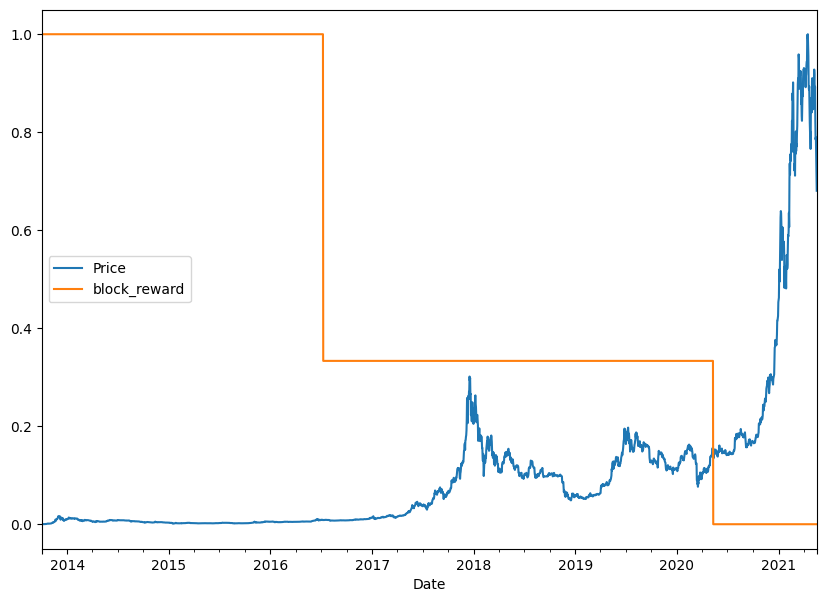

In [107]:
# Plot the block reward/price over time
# Note: Because of the different scales of our values we'll scale them to be between 0 and 1.
from sklearn.preprocessing import minmax_scale
scaled_price_block_df = pd.DataFrame(minmax_scale(bitcoin_prices_block[["Price", "block_reward"]]), # we need to scale the data first
                                     columns=bitcoin_prices_block.columns,
                                     index=bitcoin_prices_block.index)
scaled_price_block_df.plot(figsize=(10, 7));

## Making a windowed dataset with pandas

Previously, we used some custom made functions to window our univariate time series.  

However, since we've just added another variable to our dataset, these functions won't work.  

Not to worry though. Since our data is in a pandas DataFrame, we can leverage the pandas.DataFrame.shift() method to create a windowed multivariate time series.  

The shift() method offsets an index by a specified number of periods.  

Let's see it in action.  

In [108]:
# Setup dataset hyperparameters
HORIZON = 1
WINDOW_SIZE = 7

In [109]:
# Make a copy of the Bitcoin historical data with block reward feature
bitcoin_prices_windowed = bitcoin_prices_block.copy()

# Add windowed columns
for i in range(WINDOW_SIZE): # Shift values for each step in WINDOW_SIZE
  bitcoin_prices_windowed[f"Price+{i+1}"] = bitcoin_prices_windowed["Price"].shift(periods=i+1)
bitcoin_prices_windowed.head(10)

,Price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN
2013-10-06,120.65533,25,121.33866,118.67466,108.58483,125.45500,123.65499,NaN,NaN
2013-10-07,121.79500,25,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499,NaN
2013-10-08,123.03300,25,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,25,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500


In [110]:
# Let's create X & y, remove the NaN's and convert to float32 to prevent TensorFlow errors
X = bitcoin_prices_windowed.dropna().drop("Price", axis=1).astype(np.float32)
y = bitcoin_prices_windowed.dropna()["Price"].astype(np.float32)
X.head()

,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-08,25.0,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002,123.654991
2013-10-09,25.0,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831,125.455002
2013-10-10,25.0,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660,108.584831
2013-10-11,25.0,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661,118.674660
2013-10-12,25.0,125.279663,125.961159,124.049004,123.032997,121.794998,120.655327,121.338661


In [111]:
# View labels
y.head()

,Price
Date,
2013-10-08,123.032997
2013-10-09,124.049004
2013-10-10,125.961159
2013-10-11,125.279663
2013-10-12,125.927498


In [112]:
# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

## Model 6: Dense (multivariate time series)

To keep things simple, let's the model_1 architecture and use it to train and make predictions on our multivariate time series data.  

By replicating the model_1 architecture we'll be able to see whether or not adding the block reward feature improves or detracts from model performance.  

In [113]:
tf.random.set_seed(42)

# Make multivariate time series model
model_6 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  # layers.Dense(128, activation="relu"), # adding an extra layer here should lead to beating the naive model
  layers.Dense(HORIZON)
], name="model_6_dense_multivariate")

# Compile
model_6.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"])

# Fit
model_6.fit(X_train, y_train,
            epochs=100,
            batch_size=128,
            verbose=1,
            validation_data=(X_test, y_test),
            callbacks=[create_model_checkpoint(model_name=model_6.name)])

Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - loss: 854.7516 - mae: 854.7516 - val_loss: 1944.5697 - val_mae: 1944.5697
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 251.9973 - mae: 251.9973 - val_loss: 1203.3397 - val_mae: 1203.3397
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 204.7785 - mae: 204.7785 - val_loss: 1088.2947 - val_mae: 1088.2947
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 191.1761 - mae: 191.1761 - val_loss: 1099.0326 - val_mae: 1099.0326
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 187.0374 - mae: 187.0374 - val_loss: 1059.7783 - val_mae: 1059.7783
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 182.5241 - mae: 182.5241 - val_loss: 1026.0433 - val_mae: 1026.0433
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 178.7410 - mae: 178.7410 - val_loss: 1024.6458 - val_mae: 1024.6458
Epoch 8/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 173.6113 - mae: 173.6113 - val_loss: 976.4670 - v

In [114]:
# Make sure best model is loaded and evaluate
model_6 = tf.keras.models.load_model("model_experiments/model_6_dense_multivariate.keras")
model_6.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 566.6200 - mae: 566.6200


[566.6199951171875, 566.6199951171875]

In [115]:
# Make predictions on multivariate data
model_6_preds = tf.squeeze(model_6.predict(X_test))
model_6_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8859.295, 8794.745, 9040.371, 8780.683, 8736.454, 8732.446,
       8686.402, 8532.416, 8456.063, 8534.329], dtype=float32)>

In [116]:
# Evaluate preds
model_6_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_6_preds)
model_6_results

{'mae': np.float32(566.6199),
 'mse': np.float32(1170530.2),
 'rmse': np.float32(1081.9104),
 'mape': np.float32(2.5406513),
 'mase': np.float32(0.9953942)}

In [117]:
model_1_results

{'mae': np.float32(565.18585),
 'mse': np.float32(1157886.4),
 'rmse': np.float32(1076.0513),
 'mape': np.float32(2.519447),
 'mase': np.float32(0.992875)}

In [118]:
# It looks like the adding in the block reward may have helped our model slightly.

## Model 7: N-BEATS algorithm

Time to step things up a notch.  

So far we've tried a bunch of smaller models, models with only a couple of layers.  

But one of the best ways to improve a model's performance is to increase the number of layers in it.  

### Building and testing an N-BEATS block layer

In [119]:
# Create NBeatsBlock custom layer
class NBeatsBlock(tf.keras.layers.Layer):
  def __init__(self, # the constructor takes all the hyperparameters for the layer
               input_size: int,
               theta_size: int,
               horizon: int,
               n_neurons: int,
               n_layers: int,
               **kwargs): # the **kwargs argument takes care of all of the arguments for the parent class (input_shape, trainable, name)
    super().__init__(**kwargs)
    self.input_size = input_size
    self.theta_size = theta_size
    self.horizon = horizon
    self.n_neurons = n_neurons
    self.n_layers = n_layers

    # Block contains stack of 4 fully connected layers each has ReLU activation
    self.hidden = [tf.keras.layers.Dense(n_neurons, activation="relu") for _ in range(n_layers)]
    # Output of block is a theta layer with linear activation
    self.theta_layer = tf.keras.layers.Dense(theta_size, activation="linear", name="theta")

  def call(self, inputs): # the call method is what runs when the layer is called
    x = inputs
    for layer in self.hidden: # pass inputs through each hidden layer
      x = layer(x)
    theta = self.theta_layer(x)
    # Output the backcast and forecast from theta
    backcast, forecast = theta[:, :self.input_size], theta[:, -self.horizon:]
    return backcast, forecast

In [120]:
# Set up dummy NBeatsBlock layer to represent inputs and outputs
dummy_nbeats_block_layer = NBeatsBlock(input_size=WINDOW_SIZE,
                                       theta_size=WINDOW_SIZE+HORIZON, # backcast + forecast
                                       horizon=HORIZON,
                                       n_neurons=128,
                                       n_layers=4)

In [121]:
# Create dummy inputs (have to be same size as input_size)
dummy_inputs = tf.expand_dims(tf.range(WINDOW_SIZE) + 1, axis=0) # input shape to the model has to reflect Dense layer input requirements (ndim=2)
dummy_inputs

<tf.Tensor: shape=(1, 7), dtype=int32, numpy=array([[1, 2, 3, 4, 5, 6, 7]], dtype=int32)>

In [122]:
# Pass dummy inputs to dummy NBeatsBlock layer
backcast, forecast = dummy_nbeats_block_layer(dummy_inputs)
# These are the activation outputs of the theta layer (they'll be random due to no training of the model)
print(f"Backcast: {tf.squeeze(backcast.numpy())}")
print(f"Forecast: {tf.squeeze(forecast.numpy())}")


Backcast: [ 0.19971144  0.6835037   0.4849029   0.59859127 -0.46953642  0.68205917
 -0.44499484]
Forecast: 0.36288222670555115


### Preparing data for the N-BEATS algorithm using tf.data  

We've got the basic building block for the N-BEATS architecture ready to go.  

But before we use it to replicate the entire N-BEATS generic architecture, let's create some data.  

This time, because we're going to be using a larger model architecture, to ensure our model training runs as fast as possible, we'll setup our datasets using the tf.data API.  

And because the N-BEATS algorithm is focused on univariate time series, we'll start by making training and test windowed datasets of Bitcoin prices (just as we've done above).  

In [123]:
HORIZON = 1 # how far to predict forward
WINDOW_SIZE = 7 # how far to lookback

In [124]:
# Create NBEATS data inputs (NBEATS works with univariate time series)
bitcoin_prices.head()

,Price
Date,
2013-10-01,123.65499
2013-10-02,125.45500
2013-10-03,108.58483
2013-10-04,118.67466
2013-10-05,121.33866


In [125]:
# Add windowed columns
bitcoin_prices_nbeats = bitcoin_prices.copy()
for i in range(WINDOW_SIZE):
  bitcoin_prices_nbeats[f"Price+{i+1}"] = bitcoin_prices_nbeats["Price"].shift(periods=i+1)
bitcoin_prices_nbeats.dropna().head()

,Price,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,
2013-10-08,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500,123.65499
2013-10-09,124.04900,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483,125.45500
2013-10-10,125.96116,124.04900,123.03300,121.79500,120.65533,121.33866,118.67466,108.58483
2013-10-11,125.27966,125.96116,124.04900,123.03300,121.79500,120.65533,121.33866,118.67466
2013-10-12,125.92750,125.27966,125.96116,124.04900,123.03300,121.79500,120.65533,121.33866


In [126]:
# Make features and labels
X = bitcoin_prices_nbeats.dropna().drop("Price", axis=1)
y = bitcoin_prices_nbeats.dropna()["Price"]

# Make train and test sets
split_size = int(len(X) * 0.8)
X_train, y_train = X[:split_size], y[:split_size]
X_test, y_test = X[split_size:], y[split_size:]
len(X_train), len(y_train), len(X_test), len(y_test)

(2224, 2224, 556, 556)

In [127]:
# 1. Turn train and test arrays into tensor Datasets
train_features_dataset = tf.data.Dataset.from_tensor_slices(X_train)
train_labels_dataset = tf.data.Dataset.from_tensor_slices(y_train)

test_features_dataset = tf.data.Dataset.from_tensor_slices(X_test)
test_labels_dataset = tf.data.Dataset.from_tensor_slices(y_test)

# 2. Combine features & labels
train_dataset = tf.data.Dataset.zip((train_features_dataset, train_labels_dataset))
test_dataset = tf.data.Dataset.zip((test_features_dataset, test_labels_dataset))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE = 1024 # taken from Appendix D in N-BEATS paper
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset, test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>)

### Setting up hyperparameters for N-BEATS algorithm

In [128]:
# Values from N-BEATS paper Figure 1 and Table 18/Appendix D
N_EPOCHS = 5000 # called "Iterations" in Table 18
N_NEURONS = 512 # called "Width" in Table 18
N_LAYERS = 4
N_STACKS = 30

INPUT_SIZE = WINDOW_SIZE * HORIZON # called "Lookback" in Table 18
THETA_SIZE = INPUT_SIZE + HORIZON

INPUT_SIZE, THETA_SIZE

(7, 8)

### Getting ready for residual connections

Hyperparameters ready, now before we create the N-BEATS model, there are two layers to go through which play a large roll in the architecture.  

They're what make N-BEATS double residual stacking possible:   

tf.keras.layers.subtract(inputs) - subtracts list of input tensors from each other  
tf.keras.layers.add(inputs) - adds list of input tensors to each other  

In [129]:
# Make tensors
tensor_1 = tf.range(10) + 10
tensor_2 = tf.range(10)

# Subtract
subtracted = layers.subtract([tensor_1, tensor_2])

# Add
added = layers.add([tensor_1, tensor_2])

print(f"Input tensors: {tensor_1.numpy()} & {tensor_2.numpy()}")
print(f"Subtracted: {subtracted.numpy()}")
print(f"Added: {added.numpy()}")

Input tensors: [10 11 12 13 14 15 16 17 18 19] & [0 1 2 3 4 5 6 7 8 9]
Subtracted: [10 10 10 10 10 10 10 10 10 10]
Added: [10 12 14 16 18 20 22 24 26 28]


### Building, compiling and fitting the N-BEATS algorithm  

We'll do so by going through the following:

1. Setup an instance of the N-BEATS block layer using NBeatsBlock (this'll be the initial block used for the network, the rest will be created as part of stacks)  
2. Create an input layer for the N-BEATS stack (we'll be using the Keras Functional API for this)  
3. Make the initial backcast and forecasts for the model with the layer created in (1)  
4. Use a for loop to create stacks of block layers  
5. Use the NBeatsBlock class within the for loop created in (4) to create blocks which return backcasts and block-level forecasts  
6.  Create the double residual stacking using subtract and add layers  
7. Put the model inputs and outputs together using tf.keras.Model()
8. Compile the model with MAE loss (the paper uses multiple losses but we'll use MAE to keep it inline with our other models) and Adam optimizer with default settings as per section 5.2 of N-BEATS paper)
9. Fit the N-BEATS model for 5000 epochs and since it's fitting for so many epochs, we'll use a couple of callbacks:  

tf.keras.callbacks.EarlyStopping() - stop the model from training if it doesn't improve validation loss for 200 epochs and restore the best performing weights using restore_best_weights=True (this'll prevent the model from training for loooongggggg period of time without improvement)  

tf.keras.callbacks.ReduceLROnPlateau() - if the model's validation loss doesn't improve for 100 epochs, reduce the learning rate by 10x to try and help it make incremental improvements (the smaller the learning rate, the smaller updates a model tries to make)

In [130]:
 %%time

tf.random.set_seed(42)

# 1. Setup N-BEATS Block layer
nbeats_block_layer = NBeatsBlock(input_size=INPUT_SIZE,
                                 theta_size=THETA_SIZE,
                                 horizon=HORIZON,
                                 n_neurons=N_NEURONS,
                                 n_layers=N_LAYERS,
                                 name="InitialBlock")

# 2. Create input to stacks
stack_input = layers.Input(shape=(INPUT_SIZE,), name="stack_input")

# 3. Create initial backcast and forecast input (backwards predictions are referred to as residuals in the paper)
backcast, forecast = nbeats_block_layer(stack_input)
residuals = layers.subtract([stack_input, backcast], name=f"subtract_00")

# 4. Create stacks of blocks
for i, _ in enumerate(range(N_STACKS-1)): # first stack is already creted in (3)

  # 5. Use the NBeatsBlock to calculate the backcast as well as block forecast
  backcast, block_forecast = NBeatsBlock(
      input_size=INPUT_SIZE,
      theta_size=THETA_SIZE,
      horizon=HORIZON,
      n_neurons=N_NEURONS,
      n_layers=N_LAYERS,
      name=f"NBeatsBlock_{i}"
  )(residuals) # pass it in residuals (the backcast)

  # 6. Create the double residual stacking
  residuals = layers.subtract([residuals, backcast], name=f"subtract_{i}")
  forecast = layers.add([forecast, block_forecast], name=f"add_{i}")

# 7. Put the stack model together
model_7 = tf.keras.Model(inputs=stack_input,
                         outputs=forecast,
                         name="model_7_N-BEATS")

# 8. Compile with MAE loss and Adam optimizer
model_7.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(0.001),
                metrics=["mae", "mse"])

# 9. Fit the model with EarlyStopping and ReduceLROnPlateau callbacks
model_7.fit(train_dataset,
            epochs=N_EPOCHS,
            validation_data=test_dataset,
            verbose=0, # prevent large amounts of training outputs
            # callbacks=[create_model_checkpoint(model_name=stack_model.name)] # saving model every epoch consumes far too much time
            callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=200, restore_best_weights=True),
                      tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=100, verbose=1)])


Epoch 286: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 386: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
CPU times: user 1min 42s, sys: 7.89 s, total: 1min 50s
Wall time: 2min 30s


In [131]:
# Evaluate N-BEATS model on the test dataset
model_7.evaluate(test_dataset)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 576.8065 - mae: 576.8065 - mse: 1173704.7500


[576.8065185546875, 576.8065185546875, 1173704.75]

In [132]:
# Make predictions with N-BEATS model
model_7_preds = make_preds(model_7, test_dataset)
model_7_preds[:10]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8960.139, 8846.529, 9033.786, 8799.391, 8794.443, 8833.421,
       8673.613, 8554.215, 8551.075, 8534.458], dtype=float32)>

In [133]:
# Evaluate N-BEATS model predictions
model_7_results = evaluate_preds(y_true=y_test,
                                 y_pred=model_7_preds)
model_7_results


{'mae': np.float32(576.8065),
 'mse': np.float32(1173704.9),
 'rmse': np.float32(1083.3766),
 'mape': np.float32(2.6349943),
 'mase': np.float32(1.0132893)}

### Plotting the N-BEATS architecture we've created

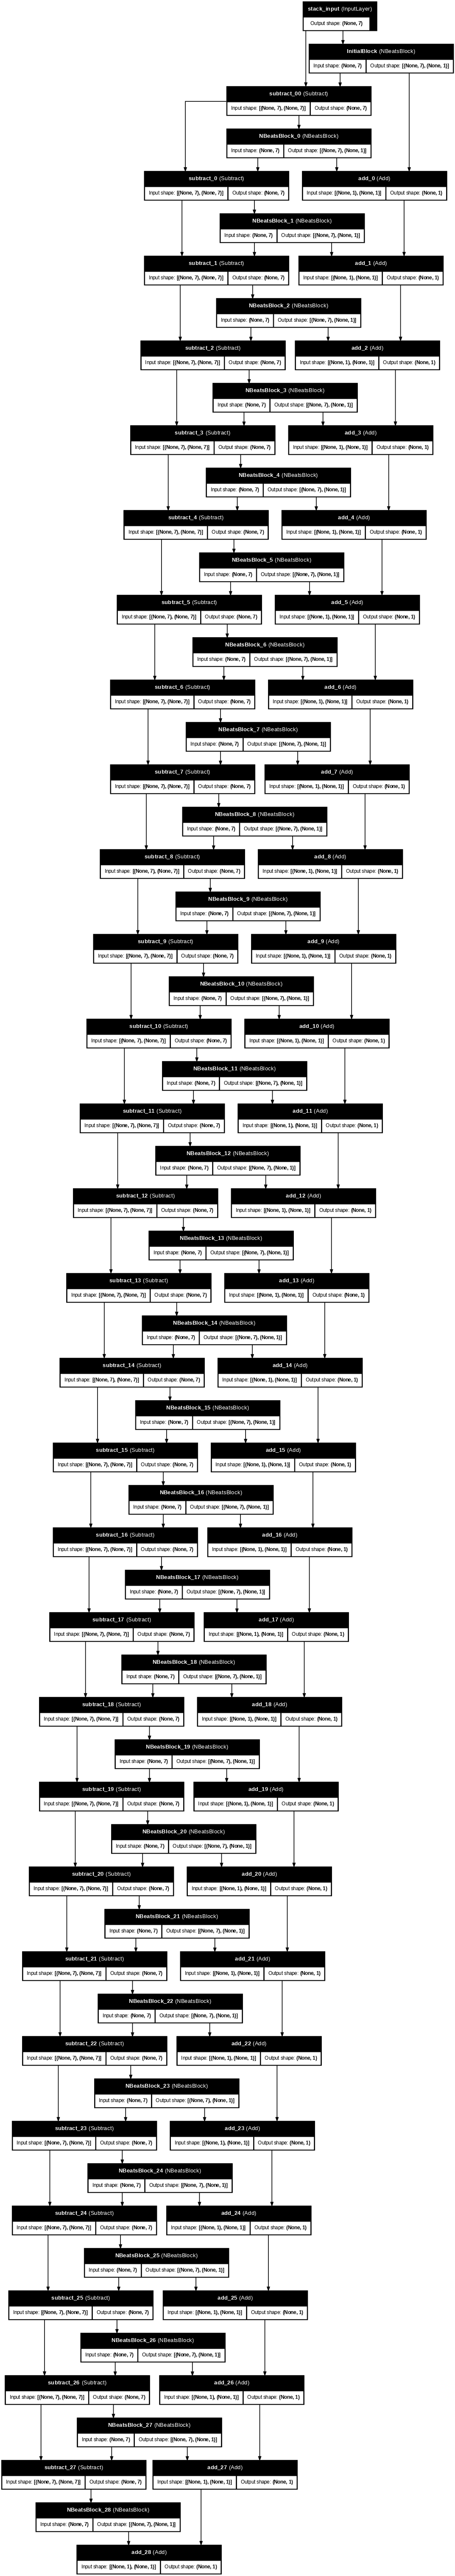

In [135]:
# Plot the N-BEATS model and inspect the architecture
from tensorflow.keras.utils import plot_model

plot_model(
    model_7,
    show_shapes=True,
    show_layer_names=True,
    expand_nested=False,
    dpi=60
)

## Model 8: Creating an ensemble (stacking different models together)

To create our ensemble models we're going to be using a combination of:  

Different loss functions (MAE, MSE, MAPE)
Randomly initialized models
Essentially, we'll be creating a suite of different models all attempting to model the same data.  

And hopefully the combined predictive power of each model is better than a single model on its own.   

Let's find out!  

### Constructing and fitting an ensemble of models (using different loss functions)

In [136]:
def get_ensemble_models(horizon=HORIZON,
                        train_data=train_dataset,
                        test_data=test_dataset,
                        num_iter=10,
                        num_epochs=100,
                        loss_fns=["mae", "mse", "mape"]):
  """
  Returns a list of num_iter models each trained on MAE, MSE and MAPE loss.

  For example, if num_iter=10, a list of 30 trained models will be returned:
  10 * len(["mae", "mse", "mape"]).
  """
  # Make empty list for trained ensemble models
  ensemble_models = []

  # Create num_iter number of models per loss function
  for i in range(num_iter):
    # Build and fit a new model with a different loss function
    for loss_function in loss_fns:
      print(f"Optimizing model by reducing: {loss_function} for {num_epochs} epochs, model number: {i}")

      # Construct a simple model (similar to model_1)
      model = tf.keras.Sequential([
        # Initialize layers with normal (Gaussian) distribution so we can use the models for prediction
        # interval estimation later: https://www.tensorflow.org/api_docs/python/tf/keras/initializers/HeNormal
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(128, kernel_initializer="he_normal", activation="relu"),
        layers.Dense(HORIZON)
      ])

      # Compile simple model with current loss function
      model.compile(loss=loss_function,
                    optimizer=tf.keras.optimizers.Adam(),
                    metrics=["mae", "mse"])

      # Fit model
      model.fit(train_data,
                epochs=num_epochs,
                verbose=0,
                validation_data=test_data,
                # Add callbacks to prevent training from going/stalling for too long
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss",
                                                            patience=200,
                                                            restore_best_weights=True),
                           tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss",
                                                                patience=100,
                                                                verbose=1)])

      # Append fitted model to list of ensemble models
      ensemble_models.append(model)

  return ensemble_models # return list of trained models


In [137]:
%%time
# Get list of trained ensemble models
ensemble_models = get_ensemble_models(num_iter=5,
                                      num_epochs=1000)

Optimizing model by reducing: mae for 1000 epochs, model number: 0

Epoch 710: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 956: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mse for 1000 epochs, model number: 0

Epoch 426: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 526: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.
Optimizing model by reducing: mape for 1000 epochs, model number: 0

Epoch 185: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.

Epoch 295: ReduceLROnPlateau reducing learning rate to 1.0000000474974514e-05.

Epoch 395: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
Optimizing model by reducing: mae for 1000 epochs, model number: 1

Epoch 597: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
Optimizing model by reducing: mse for 1000 epochs, model number: 1

Epoch 328: ReduceLROnPl

### Making predictions with an ensemble model

In [138]:
# Create a function which uses a list of trained models to make and return a list of predictions
def make_ensemble_preds(ensemble_models, data):
  ensemble_preds = []
  for model in ensemble_models:
    preds = model.predict(data) # make predictions with current ensemble model
    ensemble_preds.append(preds)
  return tf.constant(tf.squeeze(ensemble_preds))

In [139]:
# Create a list of ensemble predictions
ensemble_preds = make_ensemble_preds(ensemble_models=ensemble_models,
                                     data=test_dataset)
ensemble_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step


<tf.Tensor: shape=(15, 556), dtype=float32, numpy=
array([[ 8808.977 ,  8781.186 ,  9045.461 , ..., 49475.453 , 48551.26  ,
        46864.23  ],
       [ 8822.881 ,  8786.304 ,  9025.992 , ..., 50011.12  , 48283.69  ,
        46100.453 ],
       [ 8734.376 ,  8754.716 ,  9032.452 , ..., 50213.78  , 47988.08  ,
        45766.883 ],
       ...,
       [ 8838.763 ,  8782.54  ,  9018.551 , ..., 50552.453 , 49132.066 ,
        46676.434 ],
       [ 8727.682 ,  8791.2295,  9064.657 , ..., 50033.72  , 47918.895 ,
        46284.035 ],
       [ 8790.161 ,  8775.7   ,  9075.784 , ..., 50684.586 , 48526.61  ,
        46202.59  ]], dtype=float32)>

In [140]:
# Evaluate ensemble model(s) predictions
ensemble_results = evaluate_preds(y_true=y_test,
                                  y_pred=np.median(ensemble_preds, axis=0)) # take the median across all ensemble predictions
ensemble_results

{'mae': np.float32(567.24677),
 'mse': np.float32(1150338.9),
 'rmse': np.float32(1072.5385),
 'mape': np.float32(2.5605438),
 'mase': np.float32(0.9964954)}

### Plotting the prediction intervals (uncertainty estimates) of our ensemble

In [141]:
# Find upper and lower bounds of ensemble predictions
def get_upper_lower(preds): # 1. Take the predictions of multiple randomly initialized deep learning neural networks

  # 2. Measure the standard deviation of the predictions
  std = tf.math.reduce_std(preds, axis=0)

  # 3. Multiply the standard deviation by 1.96
  interval = 1.96 * std # https://en.wikipedia.org/wiki/1.96

  # 4. Get the prediction interval upper and lower bounds
  preds_mean = tf.reduce_mean(preds, axis=0)
  lower, upper = preds_mean - interval, preds_mean + interval
  return lower, upper

# Get the upper and lower bounds of the 95%
lower, upper = get_upper_lower(preds=ensemble_preds)

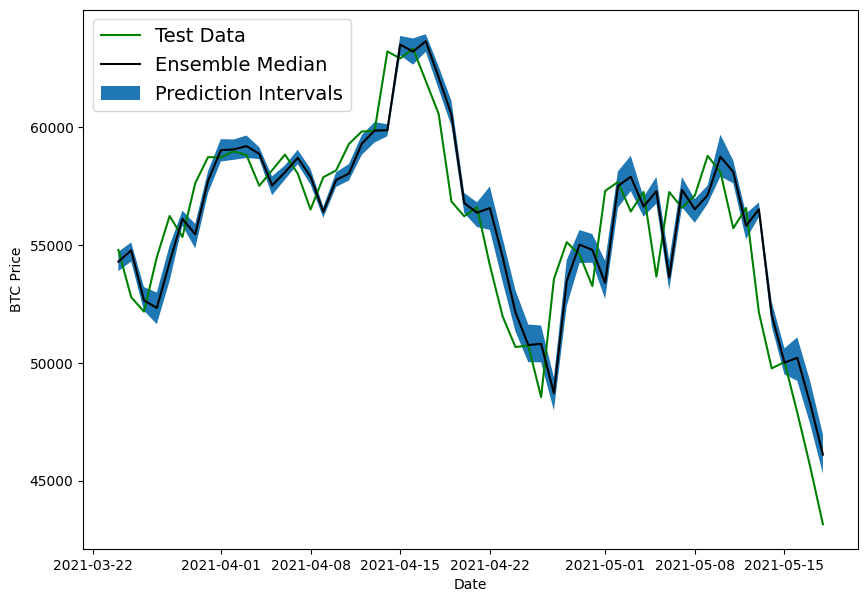

In [142]:
# Get the median values of our ensemble preds
ensemble_median = np.median(ensemble_preds, axis=0)

# Plot the median of our ensemble preds along with the prediction intervals (where the predictions fall between)
offset=500
plt.figure(figsize=(10, 7))
plt.plot(X_test.index[offset:], y_test[offset:], "g", label="Test Data")
plt.plot(X_test.index[offset:], ensemble_median[offset:], "k-", label="Ensemble Median")
plt.xlabel("Date")
plt.ylabel("BTC Price")
plt.fill_between(X_test.index[offset:],
                 (lower)[offset:],
                 (upper)[offset:], label="Prediction Intervals")
plt.legend(loc="upper left", fontsize=14);

## Model 9: Train a model on the full historical data to make predictions into future

In [143]:
bitcoin_prices_windowed.head()

,Price,block_reward,Price+1,Price+2,Price+3,Price+4,Price+5,Price+6,Price+7
Date,,,,,,,,,
2013-10-01,123.65499,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-02,125.45500,25,123.65499,NaN,NaN,NaN,NaN,NaN,NaN
2013-10-03,108.58483,25,125.45500,123.65499,NaN,NaN,NaN,NaN,NaN
2013-10-04,118.67466,25,108.58483,125.45500,123.65499,NaN,NaN,NaN,NaN
2013-10-05,121.33866,25,118.67466,108.58483,125.45500,123.65499,NaN,NaN,NaN


In [144]:
# Train model on entire data to make prediction for the next day
X_all = bitcoin_prices_windowed.drop(["Price", "block_reward"], axis=1).dropna().to_numpy() # only want prices, our future model can be a univariate model
y_all = bitcoin_prices_windowed.dropna()["Price"].to_numpy()

In [146]:
# 1. Turn X and y into tensor Datasets
features_dataset_all = tf.data.Dataset.from_tensor_slices(X_all)
labels_dataset_all = tf.data.Dataset.from_tensor_slices(y_all)

# 2. Combine features & labels
dataset_all = tf.data.Dataset.zip((features_dataset_all, labels_dataset_all))

# 3. Batch and prefetch for optimal performance
BATCH_SIZE = 1024 # taken from Appendix D in N-BEATS paper
dataset_all = dataset_all.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

dataset_all

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 7), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.float64, name=None))>

In [147]:
tf.random.set_seed(42)

# Create model (nice and simple, just to test)
model_9 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON)
])

# Compile
model_9.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam())

# Fit model on all of the data to make future forecasts
model_9.fit(dataset_all,
            epochs=100,
            verbose=0)

### Make predictions on the future

In [148]:
# How many timesteps to predict into the future?
INTO_FUTURE = 14 # since our Bitcoin data is daily, this is for 14 days

In [149]:
# 1. Create function to make predictions into the future
def make_future_forecast(values, model, into_future, window_size=WINDOW_SIZE) -> list:
  """
  Makes future forecasts into_future steps after values ends.

  Returns future forecasts as list of floats.
  """
  # 2. Make an empty list for future forecasts/prepare data to forecast on
  future_forecast = []
  last_window = values[-WINDOW_SIZE:] # only want preds from the last window (this will get updated)

  # 3. Make INTO_FUTURE number of predictions, altering the data which gets predicted on each time
  for _ in range(into_future):

    # Predict on last window then append it again, again, again (model starts to make forecasts on its own forecasts)
    future_pred = model.predict(tf.expand_dims(last_window, axis=0))
    print(f"Predicting on: \n {last_window} -> Prediction: {tf.squeeze(future_pred).numpy()}\n")

    # Append predictions to future_forecast
    future_forecast.append(tf.squeeze(future_pred).numpy())
    # print(future_forecast)

    # Update last window with new pred and get WINDOW_SIZE most recent preds (model was trained on WINDOW_SIZE windows)
    last_window = np.append(last_window, future_pred)[-WINDOW_SIZE:]

  return future_forecast

In [150]:
# Make forecasts into future of the price of Bitcoin
# Note: if you're reading this at a later date, you may already be in the future, so the forecasts
# we're making may not actually be forecasts, if that's the case, readjust the training data.
future_forecast = make_future_forecast(values=y_all,
                                       model=model_9,
                                       into_future=INTO_FUTURE,
                                       window_size=WINDOW_SIZE)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
Predicting on: 
 [56573.5554719  52147.82118698 49764.1320816  50032.69313676
 47885.62525472 45604.61575361 43144.47129086] -> Prediction: 55410.015625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
Predicting on: 
 [52147.82118698 49764.1320816  50032.69313676 47885.62525472
 45604.61575361 43144.47129086 55410.015625  ] -> Prediction: 50957.6640625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
Predicting on: 
 [49764.1320816  50032.69313676 47885.62525472 45604.61575361
 43144.47129086 55410.015625   50957.6640625 ] -> Prediction: 49328.94140625

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step
Predicting on: 
 [50032.69313676 47885.62525472 45604.61575361 43144.47129086
 55410.015625   50957.6640625  49328.94140625] -> Prediction: 49079.48828125

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Predicting on: 
 [47885.62525472 45604.61575361 43144.47129086 55410.015625
 50957.6640625  49328.94140625 49079.48828125] -> Prediction: 45485.76171875

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17

In [151]:
future_forecast[:10]

[np.float32(55410.016),
 np.float32(50957.664),
 np.float32(49328.94),
 np.float32(49079.49),
 np.float32(45485.76),
 np.float32(46461.246),
 np.float32(47941.566),
 np.float32(53688.57),
 np.float32(50132.074),
 np.float32(48334.95)]

### Plot future forecasts

In [152]:
def get_future_dates(start_date, into_future, offset=1):
  """
  Returns array of datetime values from ranging from start_date to start_date+horizon.

  start_date: date to start range (np.datetime64)
  into_future: number of days to add onto start date for range (int)
  offset: number of days to offset start_date by (default 1)
  """
  start_date = start_date + np.timedelta64(offset, "D") # specify start date, "D" stands for day
  end_date = start_date + np.timedelta64(into_future, "D") # specify end date
  return np.arange(start_date, end_date, dtype="datetime64[D]") # return a date range between start date and end date

In [153]:
# Last timestep of timesteps (currently in np.datetime64 format)
last_timestep = bitcoin_prices.index[-1]
last_timestep

Timestamp('2021-05-18 00:00:00')

In [154]:
# Get next two weeks of timesteps
next_time_steps = get_future_dates(start_date=last_timestep,
                                   into_future=INTO_FUTURE)
next_time_steps

array(['2021-05-19', '2021-05-20', '2021-05-21', '2021-05-22',
       '2021-05-23', '2021-05-24', '2021-05-25', '2021-05-26',
       '2021-05-27', '2021-05-28', '2021-05-29', '2021-05-30',
       '2021-05-31', '2021-06-01'], dtype='datetime64[D]')

In [155]:
# Insert last timestep/final price so the graph doesn't look messed
next_time_steps = np.insert(next_time_steps, 0, last_timestep)
future_forecast = np.insert(future_forecast, 0, btc_price[-1])
next_time_steps, future_forecast


(array(['2021-05-18', '2021-05-19', '2021-05-20', '2021-05-21',
        '2021-05-22', '2021-05-23', '2021-05-24', '2021-05-25',
        '2021-05-26', '2021-05-27', '2021-05-28', '2021-05-29',
        '2021-05-30', '2021-05-31', '2021-06-01'], dtype='datetime64[D]'),
 array([43144.473, 55410.016, 50957.664, 49328.94 , 49079.49 , 45485.76 ,
        46461.246, 47941.566, 53688.57 , 50132.074, 48334.95 , 47566.543,
        45425.54 , 48225.832, 50139.723], dtype=float32))

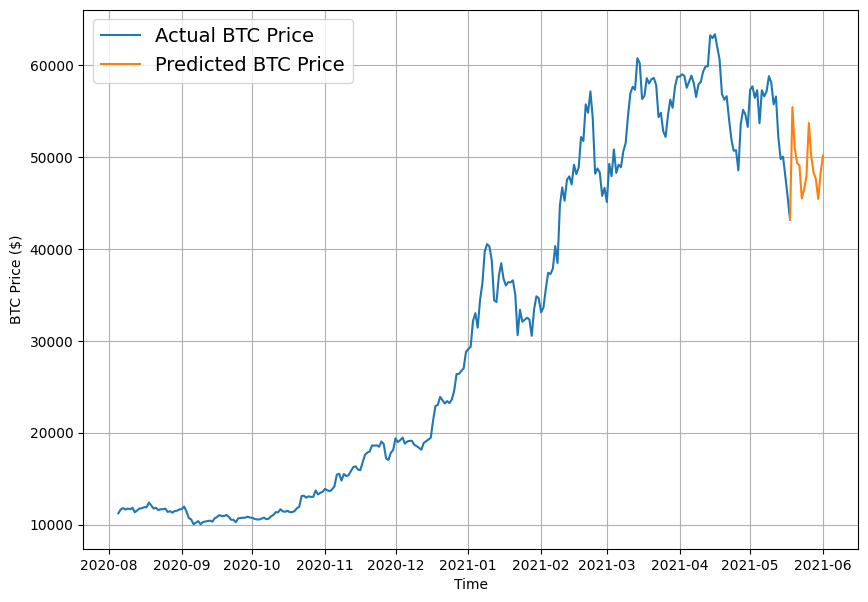

In [156]:
# Plot future price predictions of Bitcoin
plt.figure(figsize=(10, 7))
plot_time_series(bitcoin_prices.index, btc_price, start=2500, format="-", label="Actual BTC Price")
plot_time_series(next_time_steps, future_forecast, format="-", label="Predicted BTC Price")


## Model 10: Why forecasting is BS (the turkey problem 🦃)  

When creating any kind of forecast, you must keep the turkey problem in mind.  

The turkey problem is an analogy for when your observational data (your historical data) fails to capture a future event which is catostrophic and could lead you to ruin.  

The story goes, a turkey lives a good life for 1000 days, being fed every day and taken care of by its owners until the evening before Thanksgiving.  

Based on the turkey's observational data, it has no reason to believe things shouldn't keep going the way they are.  

In other words, how could a turkey possibly predict that on day 1001, after 1000 consectutive good days, it was about to have a far from ideal day.

In [157]:
# Let's introduce a Turkey problem to our BTC data (price BTC falls 100x in one day)
btc_price_turkey = btc_price.copy()
btc_price_turkey[-1] = btc_price_turkey[-1] / 100

In [158]:
# Manufacture an extra price on the end (to showcase the Turkey problem)
btc_price_turkey[-10:]

[58788.2096789273,
 58102.1914262342,
 55715.5466512869,
 56573.5554719043,
 52147.8211869823,
 49764.1320815975,
 50032.6931367648,
 47885.6252547166,
 45604.6157536131,
 431.44471290860304]

In [159]:
# Get the timesteps for the turkey problem
btc_timesteps_turkey = np.array(bitcoin_prices.index)
btc_timesteps_turkey[-10:]

array(['2021-05-09T00:00:00.000000000', '2021-05-10T00:00:00.000000000',
       '2021-05-11T00:00:00.000000000', '2021-05-12T00:00:00.000000000',
       '2021-05-13T00:00:00.000000000', '2021-05-14T00:00:00.000000000',
       '2021-05-15T00:00:00.000000000', '2021-05-16T00:00:00.000000000',
       '2021-05-17T00:00:00.000000000', '2021-05-18T00:00:00.000000000'],
      dtype='datetime64[ns]')

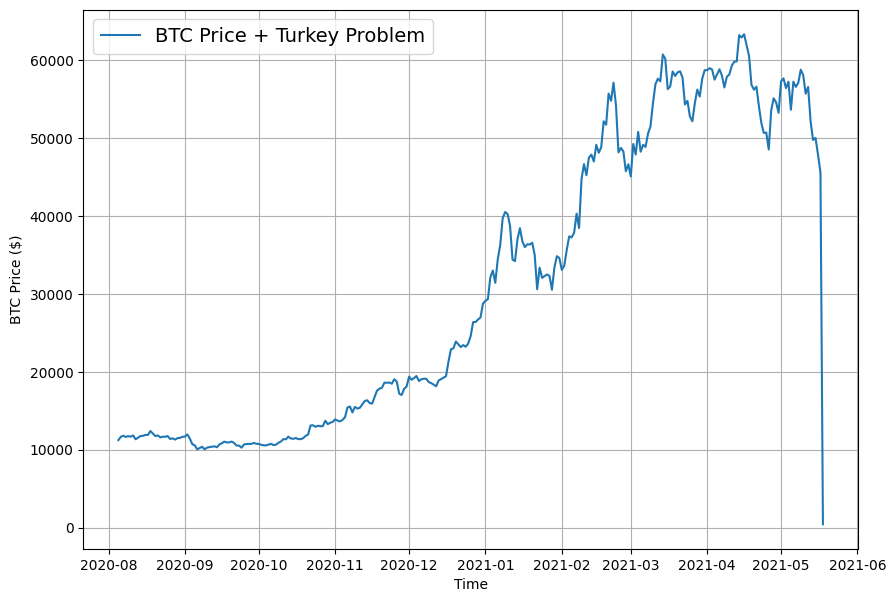

In [160]:
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=btc_timesteps_turkey,
                 values=btc_price_turkey,
                 format="-",
                 label="BTC Price + Turkey Problem",
                 start=2500)

In [162]:
# Create train and test sets for turkey problem data
full_windows, full_labels = make_windows(np.array(btc_price_turkey), windows_size=WINDOW_SIZE, horizon=HORIZON)
len(full_windows), len(full_labels)

X_train, X_test, y_train, y_test = make_train_test_splits(full_windows, full_labels)
len(X_train), len(X_test), len(y_train), len(y_test)


Window indexes:
 (array([[   0,    1,    2, ...,    5,    6,    7],
       [   1,    2,    3, ...,    6,    7,    8],
       [   2,    3,    4, ...,    7,    8,    9],
       ...,
       [2777, 2778, 2779, ..., 2782, 2783, 2784],
       [2778, 2779, 2780, ..., 2783, 2784, 2785],
       [2779, 2780, 2781, ..., 2784, 2785, 2786]]), (2780, 8))
Windowed array:
 (array([[  123.65499   ,   125.455     ,   108.58483   , ...,
          120.65533   ,   121.795     ,   123.033     ],
       [  125.455     ,   108.58483   ,   118.67466   , ...,
          121.795     ,   123.033     ,   124.049     ],
       [  108.58483   ,   118.67466   ,   121.33866   , ...,
          123.033     ,   124.049     ,   125.96116   ],
       ...,
       [58788.20967893, 58102.19142623, 55715.54665129, ...,
        49764.1320816 , 50032.69313676, 47885.62525472],
       [58102.19142623, 55715.54665129, 56573.5554719 , ...,
        50032.69313676, 47885.62525472, 45604.61575361],
       [55715.54665129, 56573.5554719

(2224, 556, 2224, 556)

### Building a turkey model (model to predict on turkey data)

In [166]:
# Clone model 1 architecture for turkey model and fit the turkey model on the turkey data
turkey_model = tf.keras.models.clone_model(model_1)
turkey_model._name = "Turkey_Model"
turkey_model.compile(loss="mae",
                     optimizer=tf.keras.optimizers.Adam())
turkey_model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0,
    validation_data=(X_test, y_test),
    callbacks=[create_model_checkpoint(model_name="Turkey_Model")]
)

In [167]:
# Evaluate turkey model on test data
turkey_model.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 662.2651 - mae: 662.2651


[662.2650756835938, 662.2650756835938]

In [168]:
# Load best model and evaluate on test data
turkey_model = tf.keras.models.load_model("model_experiments/Turkey_Model.keras")
turkey_model.evaluate(X_test, y_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 640.7418


640.7417602539062

In [169]:
# Make predictions with Turkey model
turkey_preds = make_preds(turkey_model, X_test)
turkey_preds[:10]

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


<tf.Tensor: shape=(10,), dtype=float32, numpy=
array([8835.658, 8776.72 , 9048.005, 8780.422, 8738.751, 8739.428,
       8675.07 , 8516.27 , 8460.423, 8527.449], dtype=float32)>

In [170]:
# Evaluate turkey preds
turkey_results = evaluate_preds(y_true=y_test,
                                y_pred=turkey_preds)
turkey_results

{'mae': np.float32(17132.457),
 'mse': np.float32(614614000.0),
 'rmse': np.float32(24791.41),
 'mape': np.float32(121.39659),
 'mase': np.float32(26.512533)}

In [171]:
model_1_results

{'mae': np.float32(565.18585),
 'mse': np.float32(1157886.4),
 'rmse': np.float32(1076.0513),
 'mape': np.float32(2.519447),
 'mase': np.float32(0.992875)}

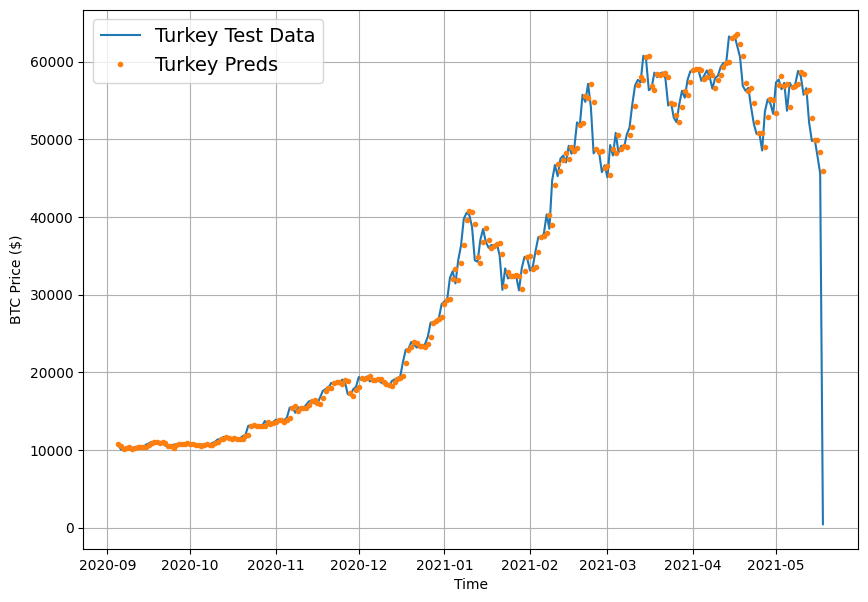

In [172]:
plt.figure(figsize=(10, 7))
# plot_time_series(timesteps=btc_timesteps_turkey[:split_size], values=btc_price_turkey[:split_size], label="Train Data")
offset=300
plot_time_series(timesteps=btc_timesteps_turkey[-len(X_test):],
                 values=btc_price_turkey[-len(y_test):],
                 format="-",
                 label="Turkey Test Data", start=offset)
plot_time_series(timesteps=btc_timesteps_turkey[-len(X_test):],
                 values=turkey_preds,
                 label="Turkey Preds",
                 start=offset);

## Compare Models

In [173]:
# Compare different model results (w = window, h = horizon, e.g. w=7 means a window size of 7)
model_results = pd.DataFrame({"naive_model": naive_results,
                              "model_1_dense_w7_h1": model_1_results,
                              "model_2_dense_w30_h1": model_2_results,
                              "model_3_dense_w30_h7": model_3_results,
                              "model_4_CONV1D": model_4_results,
                              "model_5_LSTM": model_5_results,
                              "model_6_multivariate": model_6_results,
                              "model_8_NBEATs": model_7_results,
                              "model_9_ensemble": ensemble_results,
                              "model_10_turkey": turkey_results}).T
model_results.head(10)

,mae,mse,rmse,mape,mase
naive_model,567.980225,1.147547e+06,1071.236206,2.516525,0.999570
model_1_dense_w7_h1,565.185852,1.157886e+06,1076.051270,2.519447,0.992875
model_2_dense_w30_h1,569.940613,1.173131e+06,1083.111816,2.544451,1.001228
model_3_dense_w30_h7,1237.783569,5.296453e+06,2301.402344,5.672277,2.202567
model_4_CONV1D,798.965393,2.143972e+06,1464.230957,3.594496,1.403561
model_5_LSTM,648.764160,1.457932e+06,1207.448608,2.947006,1.139699
model_6_multivariate,566.619873,1.170530e+06,1081.910400,2.540651,0.995394
model_8_NBEATs,576.806519,1.173705e+06,1083.376587,2.634994,1.013289
model_9_ensemble,567.246765,1.150339e+06,1072.538452,2.560544,0.996495
model_10_turkey,17132.457031,6.146140e+08,24791.410156,121.396591,26.512533


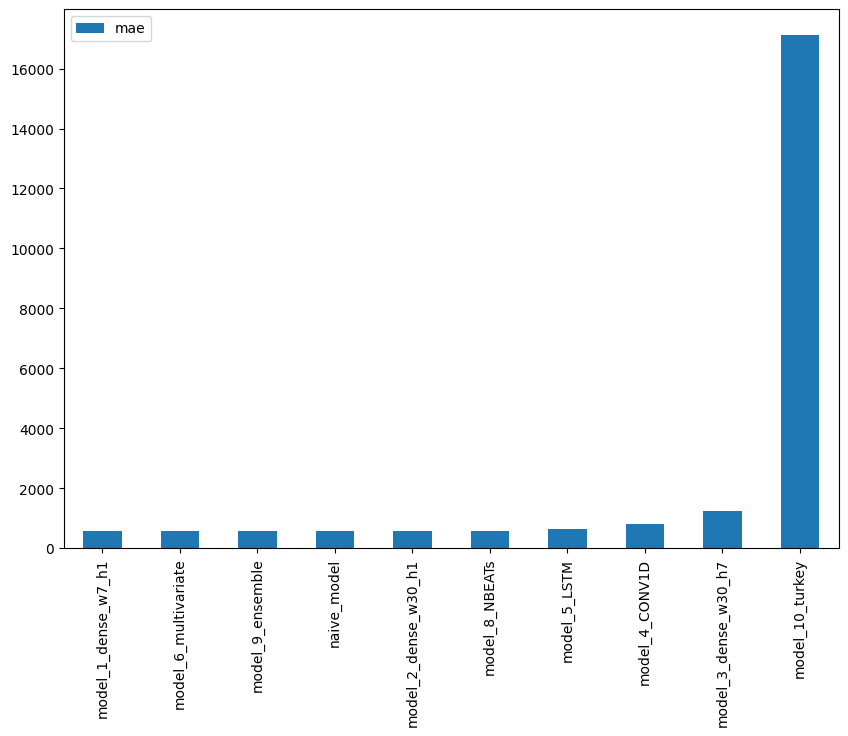

In [174]:
# Sort model results by MAE and plot them
model_results[["mae"]].sort_values(by="mae").plot(figsize=(10, 7), kind="bar");